In [ ]:
#Mounte Google Drive
from google.colab import drive
drive.mount('/content/drive')

#importing libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

Mounted at /content/drive


In [ ]:
# Loading the data
data_path = '/content/drive/MyDrive/dataset'
file_path = f'{data_path}/Galaxy10_DECals.h5'
with h5py.File(file_path, 'r') as f:
    images = np.array(f['images'])
    labels = np.array(f['ans'])

    redshift = np.array(f['redshift'])


print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

print(f"Redshift shape: {redshift.shape}")

Images shape: (17736, 256, 256, 3)
Labels shape: (17736,)
Redshift shape: (17736,)


In [ ]:
# 1.a.: Inspect redshift values
print("Checking redshift for invalid values...")
print(f"images min: {images.min():.4f}, max: {images.max():.4f}")
print(f"Nan labels: {np.isnan(labels).sum():.4f}, Unique Classes: {np.unique(labels)}")

print(f"NaN count: {np.isnan(redshift).sum()}, Inf count: {np.isinf(redshift).sum()}")
print(f"Redshift min: {np.min(redshift):.4f}, max: {np.max(redshift):.4f}")


Checking redshift for invalid values...
images min: 0.0000, max: 255.0000
Nan labels: 0.0000, Unique Classes: [0 1 2 3 4 5 6 7 8 9]
NaN count: 92, Inf count: 0
Redshift min: nan, max: nan


In [ ]:
class_names = ['Disturbed', 'Merging', 'Round Smooth', 'In-between Round Smooth',
               'Cigar Shaped Smooth', 'Barred Spiral', 'Unbarred Tight Spiral','Unbarred Loose Spiral', 'Edge-on without Bulge', 'Edge-on with Bulge']

num_classes = len(class_names)

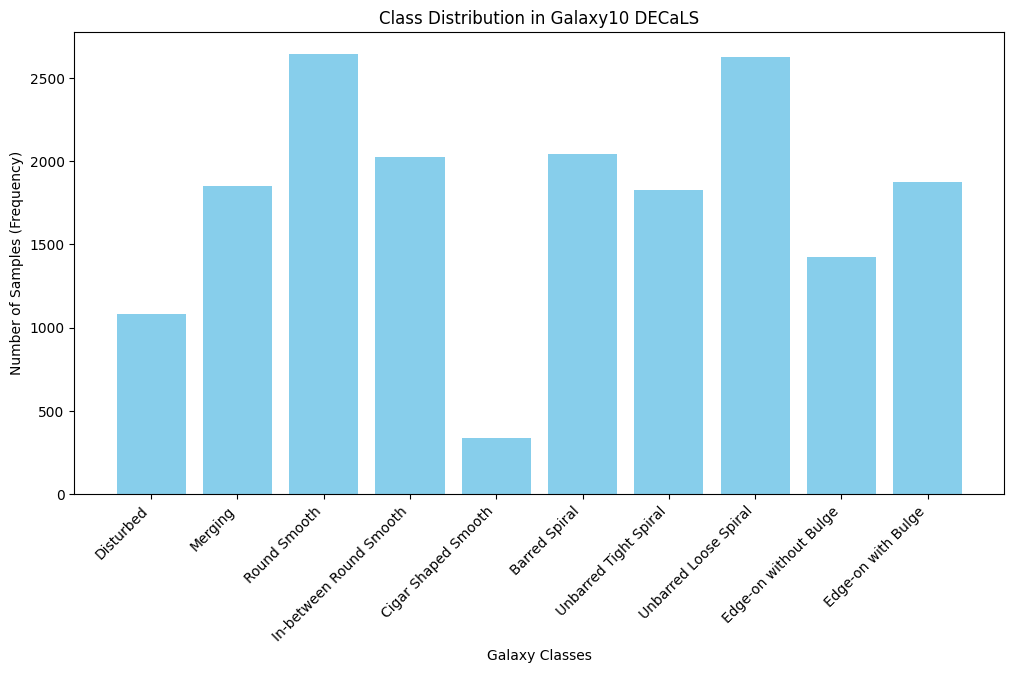

Class Distribution:
Disturbed: 1081
Merging: 1853
Round Smooth: 2645
In-between Round Smooth: 2027
Cigar Shaped Smooth: 334
Barred Spiral: 2043
Unbarred Tight Spiral: 1829
Unbarred Loose Spiral: 2628
Edge-on without Bulge: 1423
Edge-on with Bulge: 1873


In [ ]:
# distributio of galaxies
# 1.b.Class Distribution( class imbalance)
label_counts = Counter(labels)
plt.figure(figsize=(12, 6))
plt.bar(class_names, [label_counts.get(i, 0) for i in range(10)], color='skyblue')
plt.xlabel('Galaxy Classes')
plt.ylabel('Number of Samples (Frequency)')
plt.title('Class Distribution in Galaxy10 DECaLS')
plt.xticks(rotation=45, ha='right')
#plt.savefig(f'{data_path}/class_distribution_decals.png')
plt.show()


print("Class Distribution:")
for i, name in enumerate(class_names):
    print(f"{name}: {label_counts.get(i, 0)}")

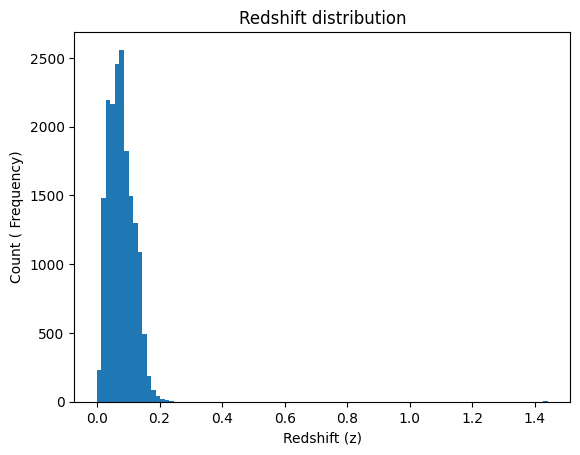

In [ ]:
#1.c.Resdhift distribution
plt.hist(redshift, bins=100)
plt.xlabel("Redshift (z)")
plt.ylabel("Count ( Frequency)")
plt.title("Redshift distribution")
plt.show()

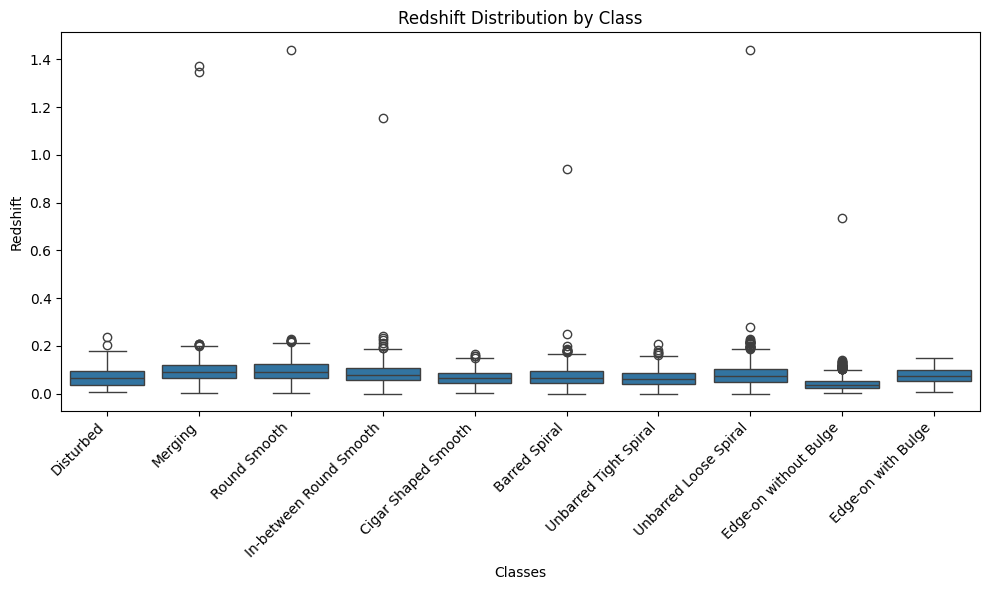

In [ ]:
# 1.d.Redshift Distribution by Class
plt.figure(figsize=(10, 6))
# Map the integer labels to class names for the x-axis using the labels
x_labels = [class_names[label] for label in labels]
# Use the redshift_raw
sns.boxplot(x=x_labels, y=redshift.flatten(),  legend=False )
plt.xlabel('Classes')
plt.ylabel('Redshift')
plt.title('Redshift Distribution by Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

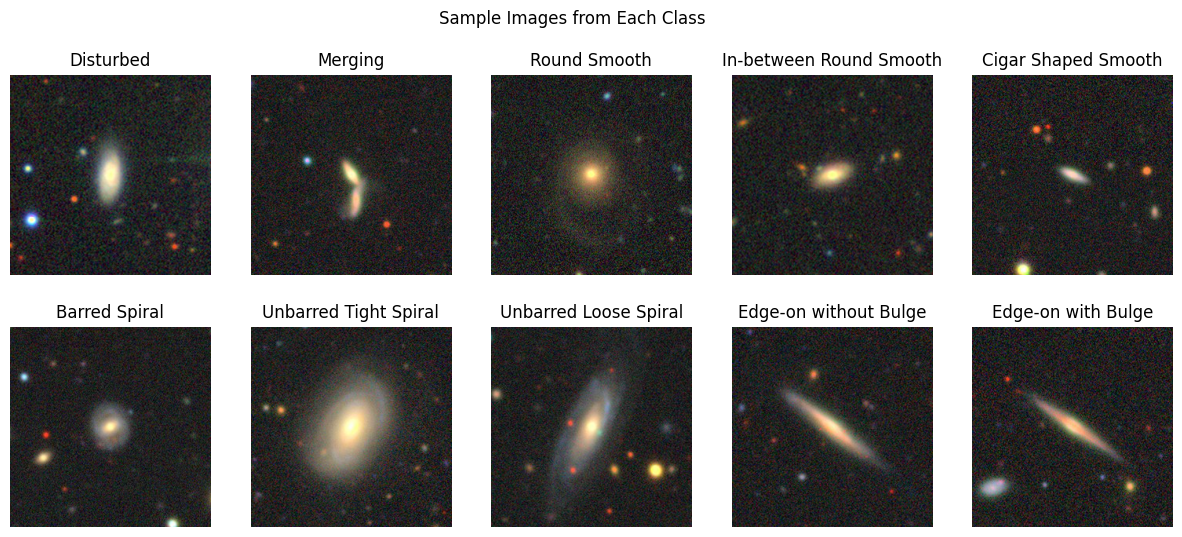

In [ ]:
# 1.e.Sample images from ecah Classes(raw samples)
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = np.random.choice(np.where(labels== i)[0])
    plt.subplot(2, 5, i+1)
    img = images[idx]
    plt.imshow(img, vmin=0, vmax=1)
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

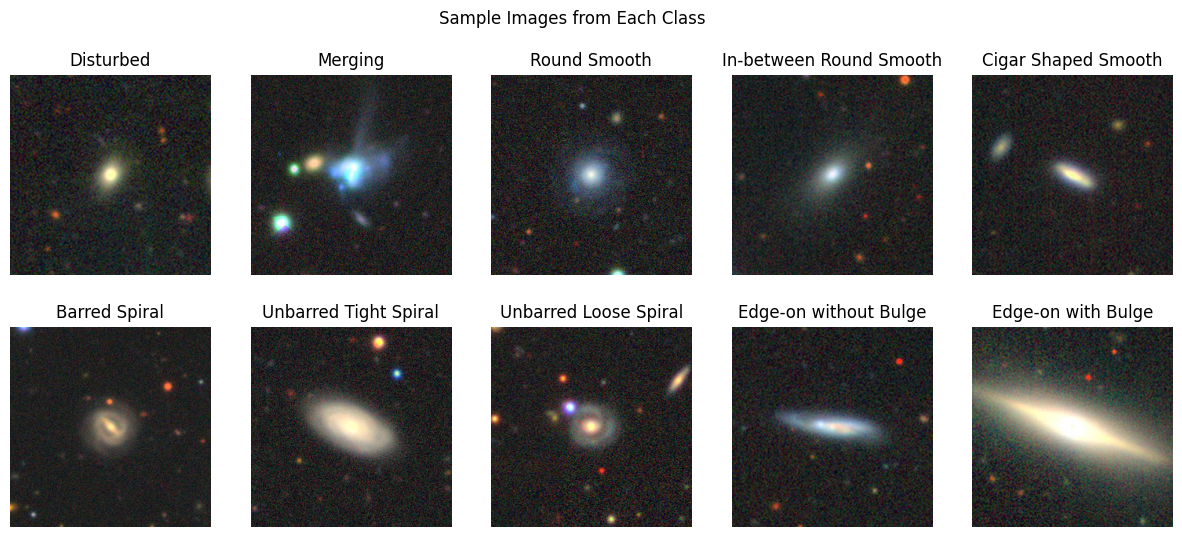

In [ ]:
# 1.e.Sample images from ecah Classes(raw samples)
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = np.random.choice(np.where(labels== i)[0])
    plt.subplot(2, 5, i+1)
    img = images[idx]
    plt.imshow(img, vmin=0, vmax=1)
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

In [ ]:
#step 2: Data cleaning process
# 2.a.Copy to avoid modifying original
redshift_clean = redshift.copy()

#a: Drop rows with NaN values
valid_mask = ~np.isnan(redshift_clean)
print(f"Removing {len(redshift_clean) - valid_mask.sum()} NaN rows")
redshift_clean = redshift_clean[valid_mask]
images_clean = images[valid_mask]
labels_clean = labels[valid_mask]


print("After cleaning:")
print("NaN count:", np.isnan(redshift_clean).sum())
print("Inf count:", np.isinf(redshift_clean).sum())
print("Min of redshift:", redshift_clean.min(), "Max of redshift:", redshift_clean.max())
print("Mean of redshift:", redshift_clean.mean(), "Std of redshift:", redshift_clean.std())

print(f"redshift_clean shape: {redshift_clean.shape}")
print(f"images_clean shape: {images_clean.shape}")
print(f"labels_clean shape: {labels_clean.shape}")

Removing 92 NaN rows
After cleaning:
NaN count: 0
Inf count: 0
Min of redshift: -0.0001244358 Max of redshift: 1.441647
Mean of redshift: 0.07750321706732066 Std of redshift: 0.04469131978755938
redshift_clean shape: (17644,)
images_clean shape: (17644, 256, 256, 3)
labels_clean shape: (17644,)


In [ ]:
# 2.b.FILTER: 0.01 < z < 0.4 (remove stars & high-z)
z_mask = (redshift_clean > 0.01) & (redshift_clean < 0.4)
print(f"Removing {len(redshift_clean) - z_mask.sum()} outlier z values")

redshift_clean = redshift_clean[z_mask]
images_clean = images_clean[z_mask]
labels_clean = labels_clean[z_mask]

print(f"redshift_clean shape: {redshift_clean.shape}")
print(f"images_clean shape: {images_clean.shape}")
print(f"labels_clean shape: {labels_clean.shape}")
print(
    redshift_clean.min(),
    redshift_clean.max(),
    redshift_clean.mean(),
    redshift_clean.std()
)

Removing 88 outlier z values
redshift_clean shape: (17556,)
images_clean shape: (17556, 256, 256, 3)
labels_clean shape: (17556,)
0.01001275 0.2805768 0.07738586230351446 0.03808624078327228


In [ ]:
#2.c.Normalized redshift by using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

z_log = np.log1p(redshift_clean)
scaler = MinMaxScaler((0, 1))
redshift_norm = scaler.fit_transform(z_log.reshape(-1, 1))

In [ ]:
print("Median:", np.median(redshift_norm))
print("NaNs:", np.isnan(redshift_norm).sum())
print("Infs:", np.isinf(redshift_norm).sum())
print("Shape:", redshift_norm.shape)


Median: 0.2571900495935905
NaNs: 0
Infs: 0
Shape: (17556, 1)


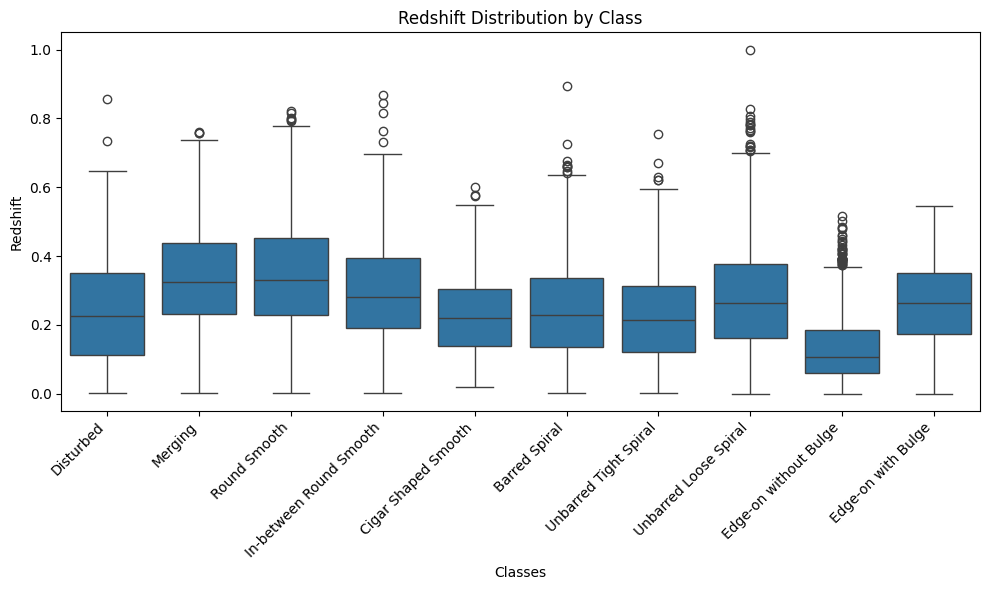

In [ ]:
# 4.4: Redshift by Class( after normalization))
plt.figure(figsize=(10, 6))
# Map the integer labels to class names for the x-axis using the cleaned labels
x_labels = [class_names[label] for label in labels_clean]
# Use the cleaned redshift_norm
sns.boxplot(x=x_labels, y=redshift_norm.flatten())
plt.xlabel('Classes')
plt.ylabel('Redshift')
plt.title('Redshift Distribution by Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig(f'{data_path}/redshift_by_class_decals.png')
#plt.close()
#print("EDA plot saved: redshift_by_class_decals.png")

plt.show()

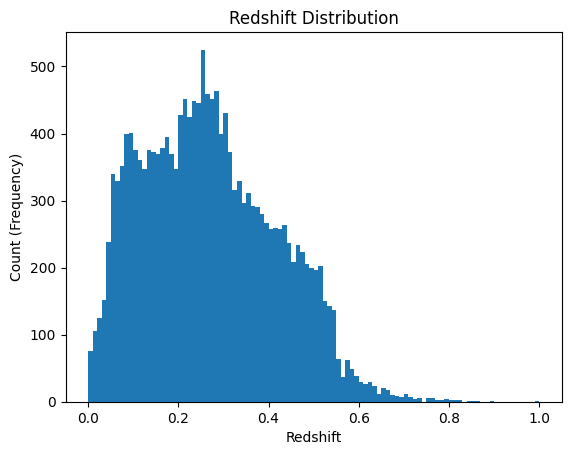

In [ ]:
# Distribution of redshift after cleaning

plt.hist(redshift_norm, bins=100)
plt.xlabel("Redshift")
plt.ylabel("Count (Frequency)")
plt.title("Redshift Distribution")
plt.show()


In [ ]:
# Step 3: Batch Resize Images/ Normalize Image
# a. Normalizing the images

batch_size = 500
num_samples = images_clean.shape[0]
resized_images = np.zeros((num_samples, 64, 64, 3), dtype=np.float32)

print("Resizing images in batches")
for i in range(0, num_samples, batch_size):
    end_idx = min(i + batch_size, num_samples)
    batch = images_clean[i:end_idx].astype('float32')  # Normalize in batch
    resized_batch = tf.image.resize(batch, [64, 64], method='bilinear').numpy()/255
    resized_images[i:end_idx] = resized_batch
    print(f"Processed batch {i//batch_size + 1}/{(num_samples-1)//batch_size + 1}")



images_resized= resized_images
print(f"After resizing, Images shape: {images_resized.shape}, Labels shape: {labels_clean.shape}")
print(f"Normalized images clean min: {images_resized.min():.4f}, max: {images_resized.max():.4f}")
print(f"Normalized images clean mean: {images_resized.mean():.4f}, std: {images_resized.std():.4f}")


Resizing images in batches
Processed batch 1/36
Processed batch 2/36
Processed batch 3/36
Processed batch 4/36
Processed batch 5/36
Processed batch 6/36
Processed batch 7/36
Processed batch 8/36
Processed batch 9/36
Processed batch 10/36
Processed batch 11/36
Processed batch 12/36
Processed batch 13/36
Processed batch 14/36
Processed batch 15/36
Processed batch 16/36
Processed batch 17/36
Processed batch 18/36
Processed batch 19/36
Processed batch 20/36
Processed batch 21/36
Processed batch 22/36
Processed batch 23/36
Processed batch 24/36
Processed batch 25/36
Processed batch 26/36
Processed batch 27/36
Processed batch 28/36
Processed batch 29/36
Processed batch 30/36
Processed batch 31/36
Processed batch 32/36
Processed batch 33/36
Processed batch 34/36
Processed batch 35/36
Processed batch 36/36
After resizing, Images shape: (17556, 64, 64, 3), Labels shape: (17556,)
Normalized images clean min: 0.0000, max: 1.0000
Normalized images clean mean: 0.1626, std: 0.1122


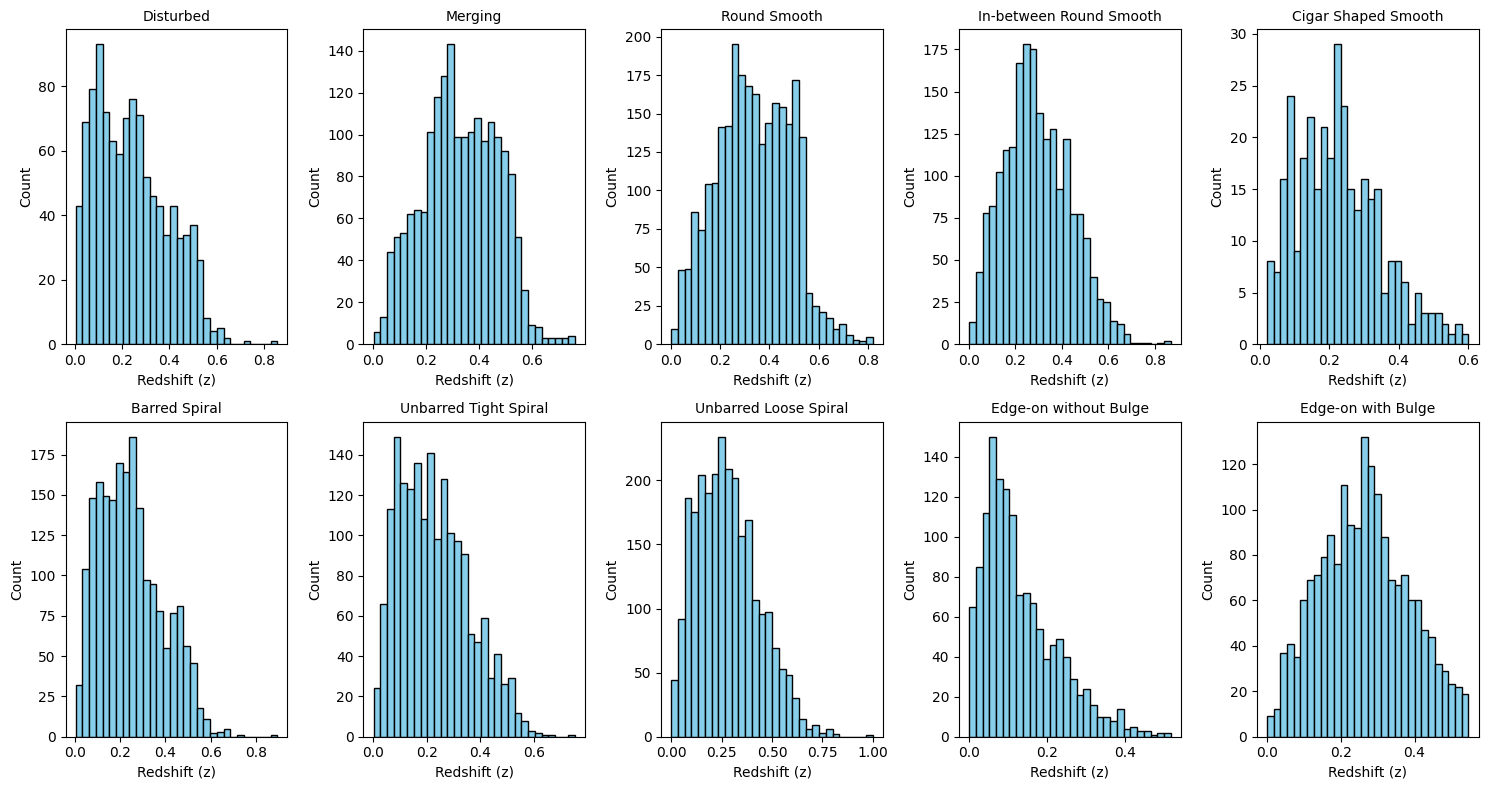

In [ ]:
plt.figure(figsize=(15, 8))
for i, cname in enumerate(class_names):
    plt.subplot(2, 5, i + 1)
    class_z = redshift_norm[labels_clean == i]
    plt.hist(class_z, bins=30, color='skyblue', edgecolor='black')
    plt.title(cname, fontsize=10)
    plt.xlabel("Redshift (z)")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

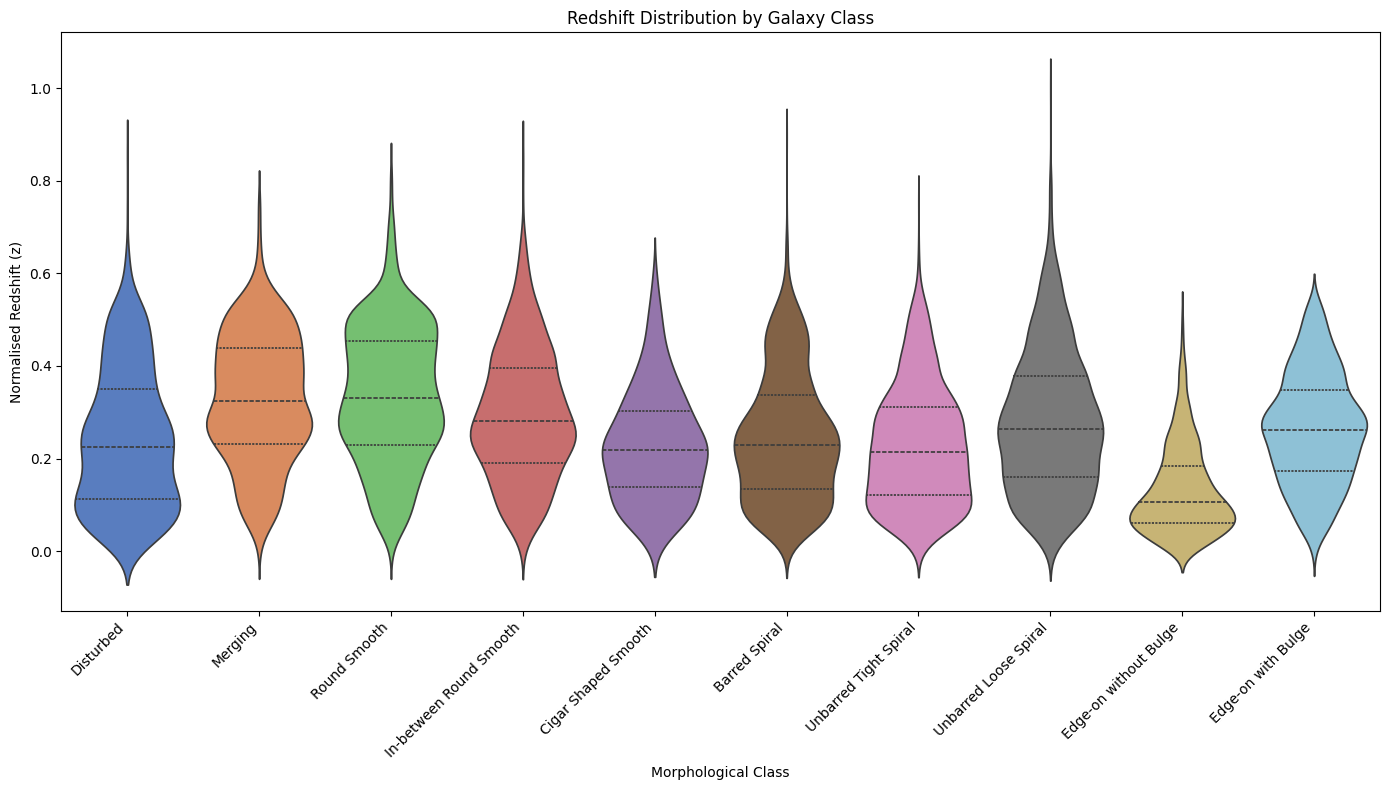

In [ ]:
# Violine Plot for Normalized redshift data
plt.figure(figsize=(14,8))
sns.violinplot(x=x_labels, y=redshift_norm.flatten(),hue=x_labels,legend=False, inner="quart", density_norm="width", palette="muted")

plt.title("Redshift Distribution by Galaxy Class")
plt.xlabel("Morphological Class")
plt.ylabel("Normalised Redshift (z)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Save preprocessed data
np.save(f'{data_path}/images_3ch.npy',images_resized )
np.save(f'{data_path}/labels_.npy', labels_clean)
np.save(f'{data_path}/redshift_norm.npy', redshift_norm)

print(f"Saved preprocessed data to {data_path}: images_aug.npy, labels_aug.npy, redshift_aug.npy")

Saved preprocessed data to /content/drive/MyDrive/dataset: images_aug.npy, labels_aug.npy, redshift_aug.npy


In [ ]:
#Load preprocessed data( after EDA )
data_path = '/content/drive/MyDrive/dataset'
images_3ch = np.load(f'{data_path}/images_3ch.npy')
labels_clean= np.load(f'{data_path}/labels_.npy')
redshift_norm = np.load(f'{data_path}/redshift_norm.npy')

class_names = ['Disturbed', 'Merging', 'Round Smooth', 'In-between Round Smooth',
               'Cigar Shaped Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
               'Unbarred Loose Spiral', 'Edge-on without Bulge', 'Edge-on with Bulge']
num_classes = len(class_names)

print(f"Loaded preprocessed data from {data_path}: images.npy, labels.npy, redshit.npy")

Loaded preprocessed data from /content/drive/MyDrive/dataset: images.npy, labels.npy, redshit.npy


In [ ]:
print(type(images_3ch))
print(type(labels_clean))
print(type(redshift_norm))

print(f"Images shape: {images_3ch.shape}, Labels clean shape: {labels_clean.shape}")
print(f"Normalized images min: {images_3ch.min():.4f}, max: {images_3ch.max():.4f}")
print(f"Normalized images mean: {images_3ch.mean():.4f}, std: {images_3ch.std():.4f}")
print(f"Normalized redshift min: {redshift_norm.min():.4f}, max: {redshift_norm.max():.4f}")
print(f"Normalized redshift shape: {redshift_norm.shape}")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Images shape: (17556, 64, 64, 3), Labels clean shape: (17556,)
Normalized images min: 0.0000, max: 1.0000
Normalized images mean: 0.1626, std: 0.1122
Normalized redshift min: 0.0000, max: 1.0000
Normalized redshift shape: (17556, 1)


In [ ]:
# data splitting by using stratify
images_train, images_temp, z_train, z_temp, y_train, y_temp = train_test_split(
    images_3ch,
    redshift_norm,
    labels_clean,
    test_size=0.30,
    stratify=labels_clean,
    random_state=42
)

images_val, images_test, z_val, z_test, y_val, y_test = train_test_split(
    images_temp,
    z_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train size:", len(images_train))
print("Val size:", len(images_val))
print("Test size:", len(images_test))

Train size: 12289
Val size: 2633
Test size: 2634


In [ ]:
# CLASS COUNTS FOR TRAINING SET

class_counts = Counter(y_train)
print("\nTraining set class counts:")
for cls in sorted(class_counts.keys()):
    print(f"Class {cls}: {class_counts[cls]}")

target_count = max(class_counts.values())
print("\nTarget count per class:", target_count)



Training set class counts:
Class 0: 745
Class 1: 1287
Class 2: 1841
Class 3: 1413
Class 4: 232
Class 5: 1418
Class 6: 1268
Class 7: 1825
Class 8: 956
Class 9: 1304

Target count per class: 1841


In [ ]:
#AUGMENTATION FUNCTION (RGb)

random_rotation = tf.keras.layers.RandomRotation(factor=0.10, fill_mode="reflect")
random_translation = tf.keras.layers.RandomTranslation(
    height_factor=0.05,
    width_factor=0.05,
    fill_mode="reflect"
)

def augment_fn(image_rgb, redshift):
    img = tf.cast(image_rgb, tf.float32)

    # geometric augmentation
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = random_rotation(img, training=True)
    img = random_translation(img, training=True)

    #photometric augmentation
    img = tf.image.random_brightness(img, max_delta=0.10)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.image.random_saturation(img, lower=0.9, upper=1.1)

    # optional noise
    def add_noise(x):
        noise = tf.random.normal(tf.shape(x), 0.0, 0.005)
        return tf.clip_by_value(x + noise, 0.0, 1.0)

    img = tf.cond(
        tf.random.uniform([]) < 0.30,
        lambda: add_noise(img),
        lambda: img
    )

    # final clip: safe pixel range
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, redshift

In [ ]:
# BUILD BALANCED DATASETS PER CLASS

AUTOTUNE = tf.data.AUTOTUNE
class_datasets = []

for cls in sorted(class_counts.keys()):
    cls_idx = np.where(y_train == cls)[0]
    n_samples = len(cls_idx)

    print(f"Class {cls}: {n_samples} → {target_count}")

    # Extract class-specific samples
    cls_imgs = images_train[cls_idx]
    cls_z    = z_train[cls_idx]
    cls_lbls = y_train[cls_idx]

    # Build dataset for this class
    cls_ds = tf.data.Dataset.from_tensor_slices((cls_imgs, cls_z, cls_lbls))
    cls_ds = cls_ds.shuffle(n_samples, reshuffle_each_iteration=True)

    # Apply augmentation (RGB only)
    cls_ds = cls_ds.map(
        lambda img, z, lbl: (augment_fn(img, z)[0], z, lbl),
        num_parallel_calls=AUTOTUNE
    )

    # Oversample smaller classes
    if n_samples < target_count:
        repeats = (target_count // n_samples) + 1
        cls_ds = cls_ds.repeat(repeats)

    # Take exactly target_count samples
    cls_ds = cls_ds.take(target_count)

    # Shuffle again after balancing
    cls_ds = cls_ds.shuffle(target_count)

    # Format for late-fusion model
    cls_ds = cls_ds.map(
        lambda img, z, lbl: (
            {
                'image_input': img,
                'redshift_input': tf.cast(z, dtype=tf.float32)
            },
            lbl
        ),
        num_parallel_calls=AUTOTUNE
    )

    class_datasets.append(cls_ds)
print("\nClass datasets created:", len(class_datasets))
print("Each class now has exactly", target_count, "samples (after augmentation & balancing)")

Class 0: 745 → 1841
Class 1: 1287 → 1841
Class 2: 1841 → 1841
Class 3: 1413 → 1841
Class 4: 232 → 1841
Class 5: 1418 → 1841
Class 6: 1268 → 1841
Class 7: 1825 → 1841
Class 8: 956 → 1841
Class 9: 1304 → 1841

Class datasets created: 10
Each class now has exactly 1841 samples (after augmentation & balancing)


In [ ]:
# Train dataset after augmentation
balanced_ds = class_datasets[0]
for ds in class_datasets[1:]:
    balanced_ds = balanced_ds.concatenate(ds)

batch_size = 64

train_ds = (
    balanced_ds
    .shuffle(20000, reshuffle_each_iteration=True)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

print(" Final train_ds ready (balanced & augmented)")

 Final train_ds ready (balanced & augmented)


In [ ]:
# VALIDATION & TEST DATASETS (NO AUGMENTATION)

def format_inputs(image, redshift, label):
    return {
        'image_input': image,
        'redshift_input': tf.cast(redshift, dtype=tf.float32)
    }, label

val_ds = (
    tf.data.Dataset.from_tensor_slices((images_val, z_val, y_val))
    .map(format_inputs)
    .batch(32)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((images_test, z_test, y_test))
    .map(format_inputs)
    .batch(32)
    .prefetch(AUTOTUNE)
)

print("val_ds and test_ds ready (clean, no augmentation)")


val_ds and test_ds ready (clean, no augmentation)


In [ ]:
# checking the dataset
for inputs, lab in train_ds.take(1):
    print("Inputs shape:", inputs['image_input'].shape)
    print("Redshift shape:", inputs['redshift_input'].shape)
    print("Labels shape:", lab.shape)
for inputs, lab in val_ds.take(1):
    print("Inputs shape:", inputs['image_input'].shape)
    print("Redshift shape:", inputs['redshift_input'].shape)
    print("Labels shape:", lab.shape)
for inputs, lab in test_ds.take(1):
    print("Inputs shape:", inputs['image_input'].shape)
    print("Redshift shape:", inputs['redshift_input'].shape)
    print("Labels shape:", lab.shape)

Inputs shape: (64, 64, 64, 3)
Redshift shape: (64, 1)
Labels shape: (64,)
Inputs shape: (32, 64, 64, 3)
Redshift shape: (32, 1)
Labels shape: (32,)
Inputs shape: (32, 64, 64, 3)
Redshift shape: (32, 1)
Labels shape: (32,)


Collected classes: dict_keys([1, 0, 7, 9, 6, 3, 2, 5, 8, 4])


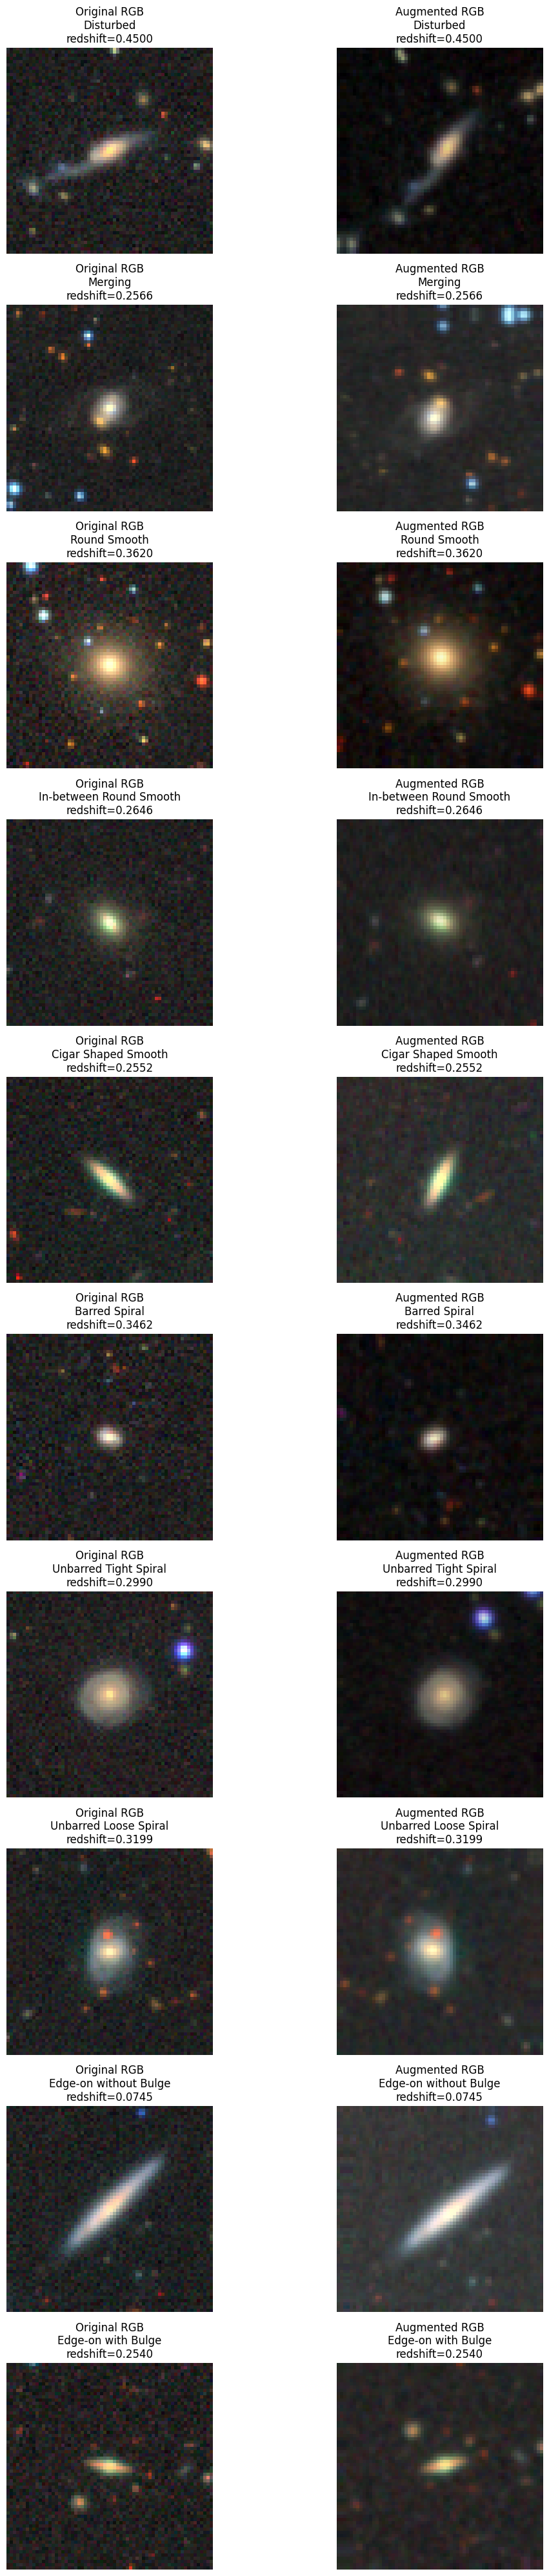

In [ ]:
# visulization to check original rgb only and augmented with redshift values
# 1. Collect one RGB image and its redshift per class
num_classes = 10
class_examples = {}   # {class_id: (image_rgb, redshift)}

for img, z, lab in zip(images_train, z_train, y_train):
    lab = int(lab)
    if lab not in class_examples:
        class_examples[lab] = (img, z)
    if len(class_examples) == num_classes:
        break

print("Collected classes:", class_examples.keys())



# 2. Apply augmentation to RGB images only
aug_examples = {}

for lab, (img, z) in class_examples.items():
    aug_img, _ = augment_fn(tf.constant(img), tf.constant(z))
    aug_examples[lab] = aug_img.numpy()



# 3. Plot (10 rows × 2 columns)
plt.figure(figsize=(12, 40))

for idx, lab in enumerate(sorted(class_examples.keys())):

    orig_img, orig_z = class_examples[lab]
    orig_z = orig_z.item()
    aug_img = aug_examples[lab]

    class_name = class_names[lab]

    # Column 1 — Original RGB
    plt.subplot(10, 2, 2*idx + 1)
    plt.imshow(orig_img)
    plt.title(f"Original RGB\n{class_name}\nredshift={orig_z:.4f}")
    plt.axis("off")

    # Column 2 — Augmented RGB
    plt.subplot(10, 2, 2*idx + 2)
    plt.imshow(aug_img)
    plt.title(f"Augmented RGB\n{class_name}\nredshift={orig_z:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()


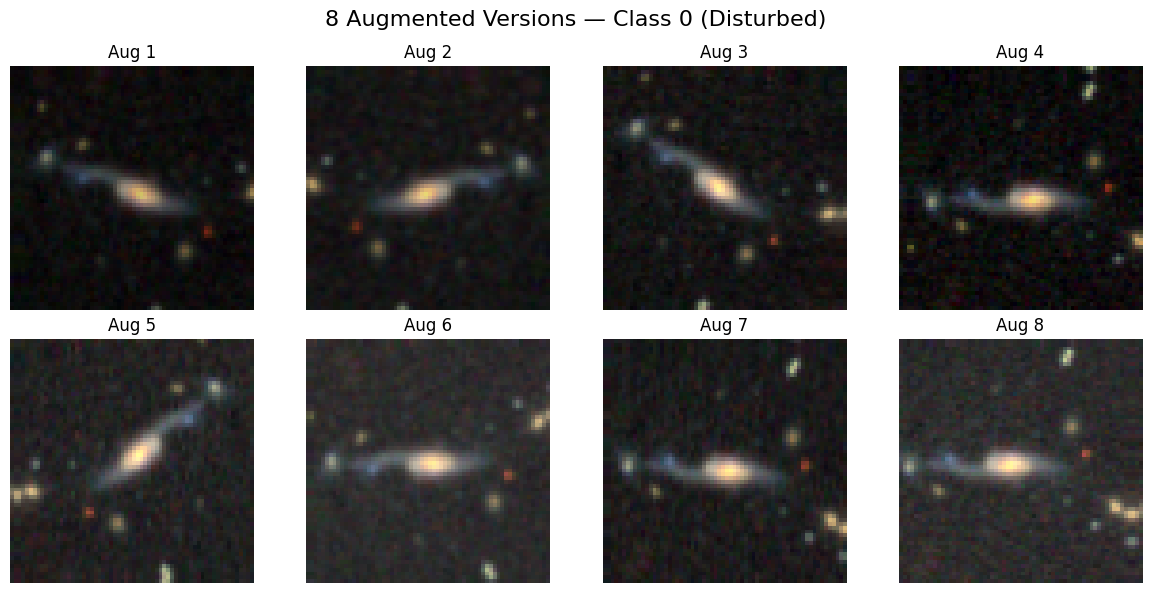

In [ ]:

# TEST : Generate 8 augmented versions of 1 image
sample_lab = 0
sample_img, sample_z = class_examples[sample_lab]

plt.figure(figsize=(12, 6))

for i in range(8):

    # Augment (only RGB image changes, redshift stays same)
    aug_img, _ = augment_fn(tf.constant(sample_img), tf.constant(sample_z))

    # Convert to numpy and clip
    aug_rgb = np.clip(aug_img.numpy(), 0, 1)

    plt.subplot(2, 4, i+1)
    plt.imshow(aug_rgb)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.suptitle(
    f"8 Augmented Versions — Class {sample_lab} ({class_names[sample_lab]})",
    fontsize=16
)
plt.tight_layout()
plt.show()


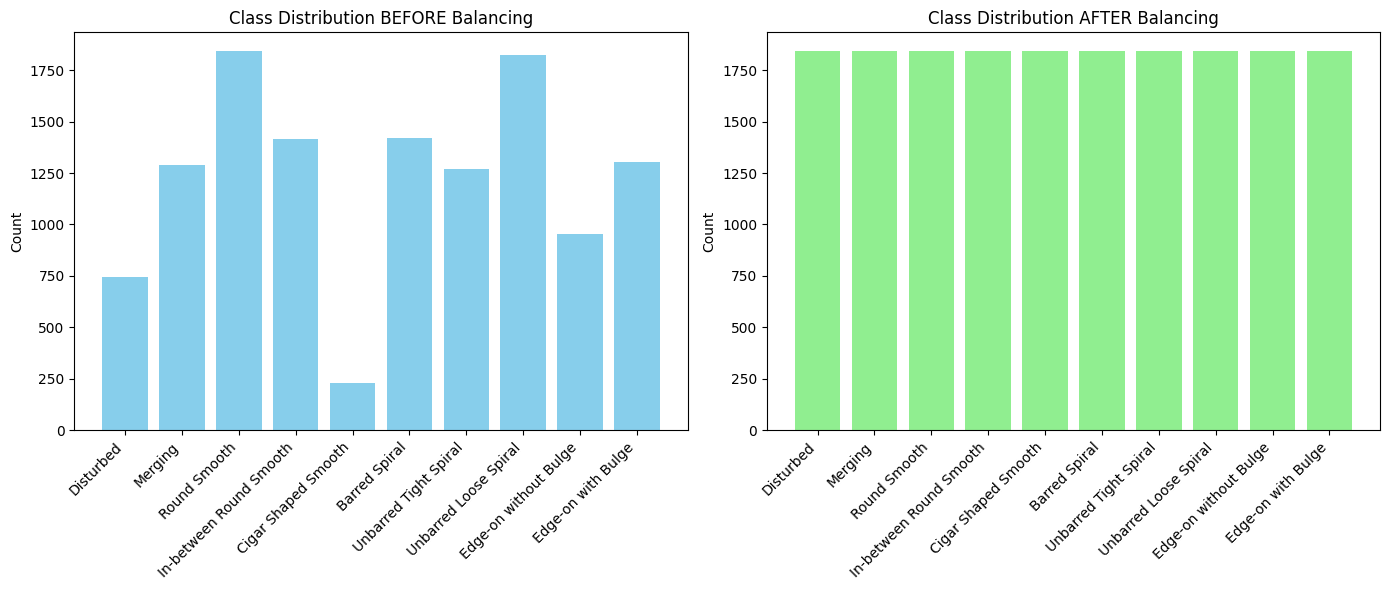


Counts after balancing:
Class 0: 1841
Class 1: 1841
Class 2: 1841
Class 3: 1841
Class 4: 1841
Class 5: 1841
Class 6: 1841
Class 7: 1841
Class 8: 1841
Class 9: 1841


In [ ]:

#  Distribution BEFORE and AFTER Balancing
# BEFORE augmentation & balancing
counts_before = Counter(y_train)

batch_size = 64
num_classes = 10

# Total balanced samples = target_count × 10 classes
num_samples = target_count * num_classes
num_batches = int(np.ceil(num_samples / batch_size))

# AFTER augmentation & balancing
all_labels = []
for _, lab_batch in train_ds.take(num_batches):
    all_labels.extend(lab_batch.numpy())

counts_after = Counter(all_labels)



# Plotting

plt.figure(figsize=(14, 6))

# BEFORE
plt.subplot(1, 2, 1)
plt.bar(range(num_classes), [counts_before[i] for i in range(num_classes)], color='skyblue')
plt.title("Class Distribution BEFORE Balancing")
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.ylabel("Count")

# AFTER
plt.subplot(1, 2, 2)
plt.bar(range(num_classes), [counts_after[i] for i in range(num_classes)], color='lightgreen')
plt.title("Class Distribution AFTER Balancing")
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Print counts
print("\nCounts after balancing:")
for i in range(num_classes):
    print(f"Class {i}: {counts_after[i]}")


In [ ]:
# extracting rgb images only
train_ds_rgb = train_ds.map(lambda x, y: (x["image_input"], y))
val_ds_rgb   = val_ds.map(lambda x, y: (x["image_input"], y))
test_ds_rgb  = test_ds.map(lambda x, y: (x["image_input"], y))


In [ ]:
# checking shape of rgb data
for img_batch, lab_batch, in train_ds_rgb.take(1):
    print("Images shape:", img_batch.shape)
    print("Labels shape:", lab_batch.shape)
for img_batch, lab_batch, in val_ds_rgb.take(1):
    print("Images shape:", img_batch.shape)
    print("Labels shape:", lab_batch.shape)
for img_batch, lab_batch, in test_ds_rgb.take(1):
    print("Images shape:", img_batch.shape)
    print("Labels shape:", lab_batch.shape)


Images shape: (64, 64, 64, 3)
Labels shape: (64,)
Images shape: (32, 64, 64, 3)
Labels shape: (32,)
Images shape: (32, 64, 64, 3)
Labels shape: (32,)


In [ ]:
# Model A- CNN Base line(without Redshift)


def build_cnn_rgb(
    input_shape=(64, 64, 3),
    num_classes=10,
    dropout_rate=0.21
):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense head
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    logits = layers.Dense(num_classes)(x)

    return models.Model(inputs, logits, name="CNN_RGB_BASELINE")


In [ ]:
# Building and compiling the model A
model_rgb = build_cnn_rgb()
model_rgb.build(input_shape=(None, 64, 64, 3))
model_rgb.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"])
model_rgb.summary()

Model: "CNN_RGB_BASELINE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 256)      │             

 Total params: 1,276,074 (4.87 MB)

 Trainable params: 1,274,154 (4.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# Callbacks for Model A
callbacks_rgb = [
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode ='max',
        patience=15,
        min_delta = 0.001,
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate reduction
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    # Model checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        "models/cnn_rgb_best2.keras",
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )]

In [ ]:
# Training of Model A
start_time = time.time()
history_rgb = model_rgb.fit(
    train_ds_rgb,
    validation_data=val_ds_rgb,
    epochs=100,
    callbacks=callbacks_rgb,
    verbose = 1
)
end_time = time.time()
training_time_sec = end_time - start_time
print(f"Training time (seconds): {training_time_sec:.2f}")

Epoch 1/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2511 - loss: 2.0806
Epoch 1: val_accuracy improved from -inf to 0.17660, saving model to models/cnn_rgb_best2.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.2515 - loss: 2.0796 - val_accuracy: 0.1766 - val_loss: 2.5079 - learning_rate: 3.0000e-04
Epoch 2/100
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5102 - loss: 1.3819
Epoch 2: val_accuracy improved from 0.17660 to 0.30498, saving model to models/cnn_rgb_best2.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5103 - loss: 1.3815 - val_accuracy: 0.3050 - val_loss: 1.8393 - learning_rate: 3.0000e-04
Epoch 3/100
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5833 - loss: 1.1969
Epoch 3: val_accuracy improved from 0.30498 to 0.49297, saving model to models/cnn_rgb_best2.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5834 - loss: 1.1966 - val_accuracy: 0.4930 - val_loss: 1.4199 - learning_rate: 3.0000e-04
Epoch 4

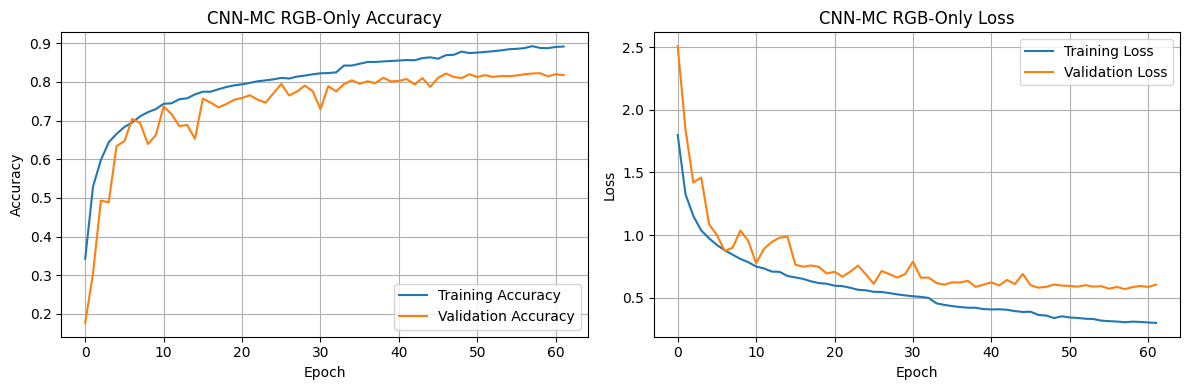

In [ ]:
# training and validation curve plot for Model A

def plot_training_history(history, model_name="Model"): # Added model_name parameter with a default value
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} Accuracy') # Used f-string for dynamic title
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} Loss') # Used f-string for dynamic title
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history_rgb, model_name="CNN-MC RGB-Only")

In [ ]:
# Standard test evaluation
test_loss, test_acc = model_rgb.evaluate(test_ds_rgb, verbose=1)

print(f"Test Accuracy (Classical): {test_acc:.4f}")
print(f"Test Loss       (Classical): {test_loss:.4f}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7903 - loss: 0.6357
Test Accuracy (Classical): 0.7954
Test Loss       (Classical): 0.5933


In [ ]:
# Class for the Prediction for CNN RGB

def get_classical_predictions(model, test_ds_rgb):
    all_preds = []
    all_labels = []

    # test_ds returns → (inputs_dict, labels)
    for images, labels in test_ds_rgb:

        # Run model (dropout disabled)
        logits = model(images, training=False)

        # Convert logits → probabilities
        probs = tf.nn.softmax(logits, axis=-1)

        all_preds.append(probs.numpy())
        all_labels.append(labels.numpy())

    # Combine batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Convert probabilities → predicted class indices
    y_pred_rgb = np.argmax(all_preds, axis=1)
    y_true_rgb = all_labels

    return y_true_rgb, y_pred_rgb


In [ ]:
# Classical Model Evaluation for CNN RGB
y_true_rgb, y_pred_rgb = get_classical_predictions(model_rgb, test_ds_rgb)

accuracy  = accuracy_score(y_true_rgb, y_pred_rgb)
precision = precision_score(y_true_rgb, y_pred_rgb, average='macro')
recall    = recall_score(y_true_rgb, y_pred_rgb, average='macro')
f1        = f1_score(y_true_rgb, y_pred_rgb, average='macro')

print("Classical Model Evaluation (No MC Dropout, RGB only)")
print("--------------------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Classical Model Evaluation (No MC Dropout, RGB only)
--------------------------------------------------
Accuracy : 0.7957
Precision: 0.7709
Recall   : 0.7977
F1-score : 0.7798


In [ ]:
print("\nClassification Report (Macro averaged) rgb only:")
print(classification_report(y_true_rgb, y_pred_rgb, target_names=class_names))


Classification Report (Macro averaged) rgb only:
                         precision    recall  f1-score   support

              Disturbed       0.43      0.53      0.47       159
                Merging       0.84      0.86      0.85       275
           Round Smooth       0.95      0.84      0.89       395
In-between Round Smooth       0.92      0.90      0.91       303
    Cigar Shaped Smooth       0.59      0.88      0.70        50
          Barred Spiral       0.73      0.83      0.78       304
  Unbarred Tight Spiral       0.75      0.71      0.73       271
  Unbarred Loose Spiral       0.70      0.63      0.66       392
  Edge-on without Bulge       0.88      0.90      0.89       205
     Edge-on with Bulge       0.93      0.90      0.91       280

               accuracy                           0.80      2634
              macro avg       0.77      0.80      0.78      2634
           weighted avg       0.81      0.80      0.80      2634



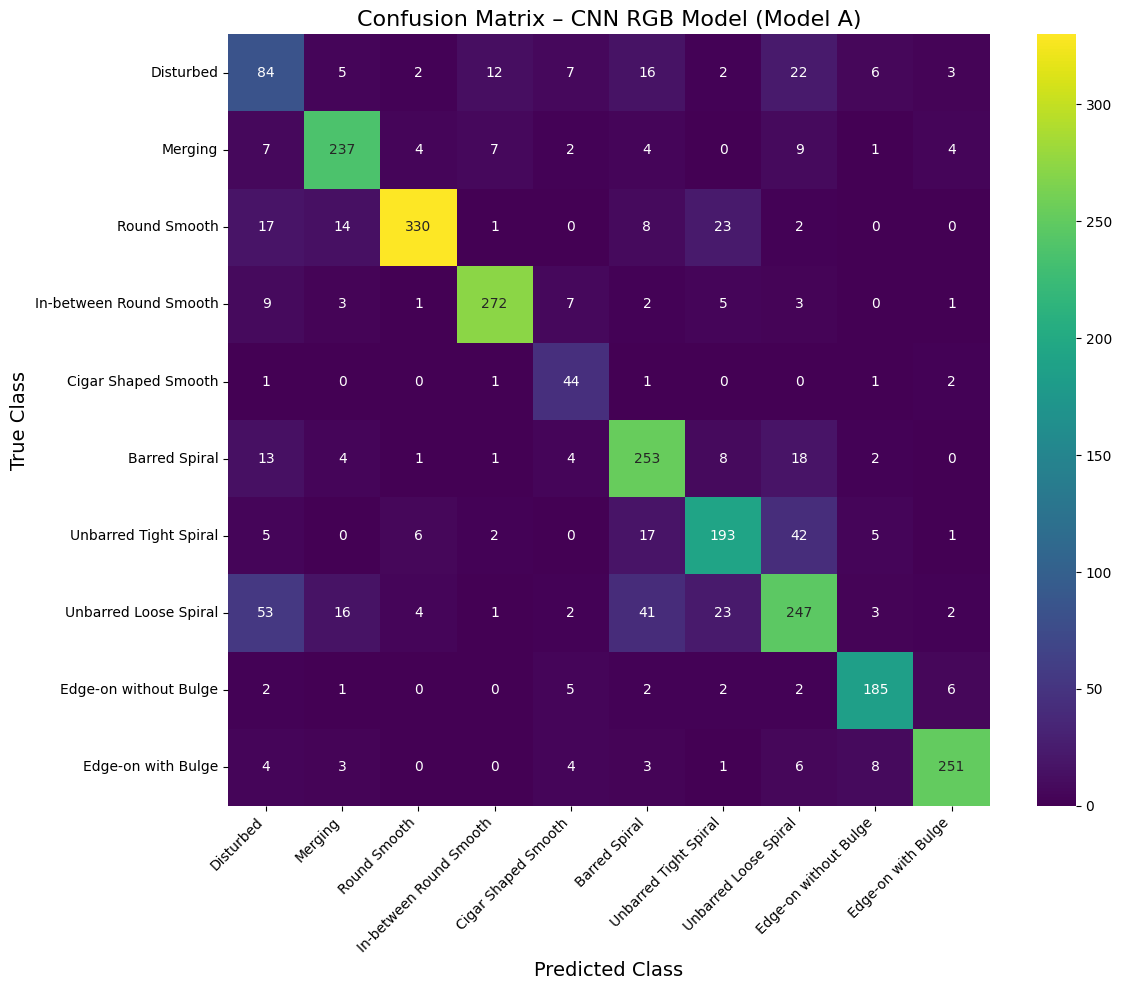

In [ ]:
# Compute confusion matrix for Model A
cm = confusion_matrix(y_true_rgb, y_pred_rgb)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt="d",           # integer formatting
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – CNN RGB Model (Model A)", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


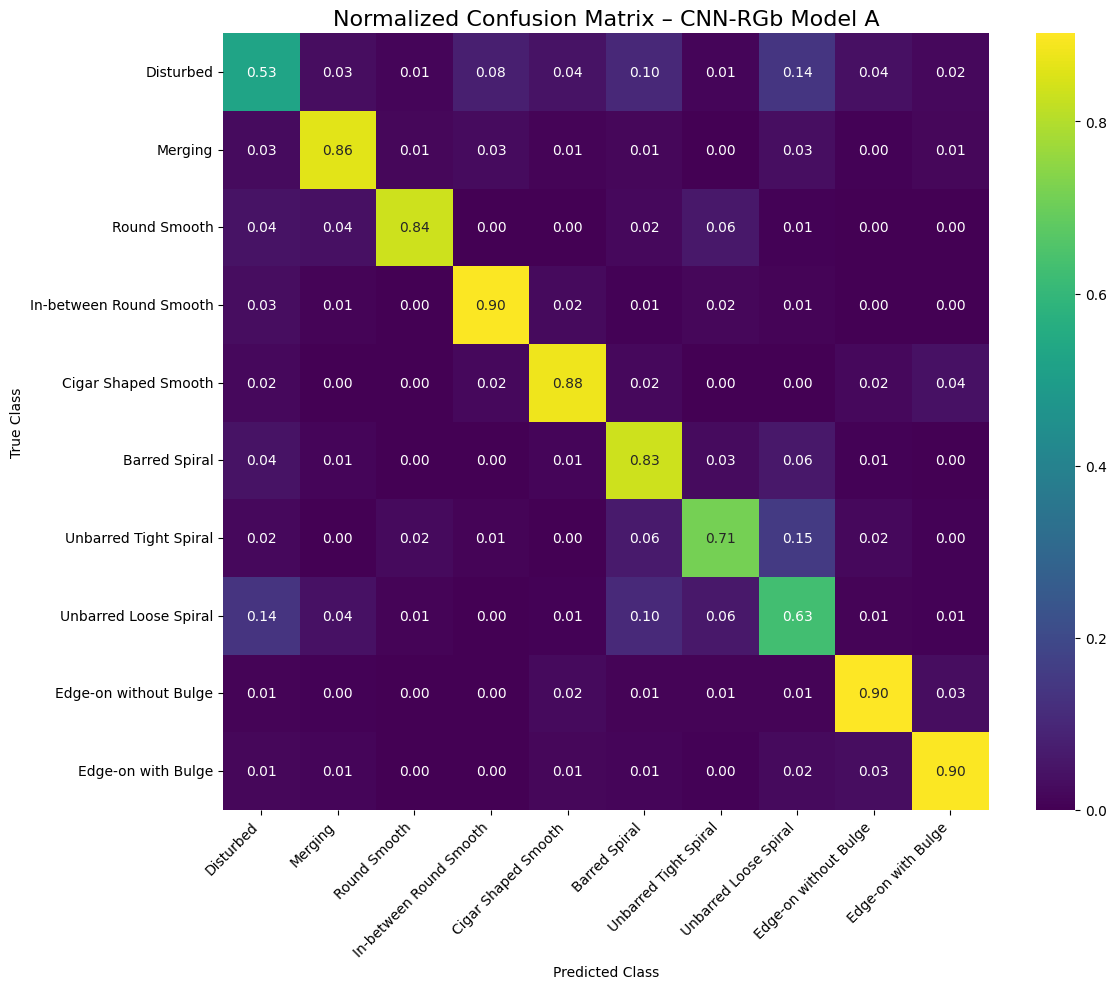

In [ ]:
# Normalized Confusion Matrix for Model A
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix – CNN-RGb Model A", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Model B- CNN with late Fusion redshift
def build_galaxynet_cnn_latefusion(
    dropout_p=0.21,
    num_classes=10
):

    # IMAGE INPUT
    image_input = layers.Input(shape=(64, 64, 3), name="image_input")

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Global pooling
    img_features = layers.GlobalAveragePooling2D()(x)

    # REDSHIFT BRANCH
    redshift_input = layers.Input(shape=(1,), name="redshift_input")

    z = layers.Dense(64, activation="relu")(redshift_input)

    z = layers.Dense(32, activation="relu")(z)


    #. Multi-dimensional gating (32 gates)
    gate = layers.Dense(32, activation="sigmoid", name="z_gate")(z)
    z_weighted = layers.Multiply(name="z_weighted")([z, gate])




    # LATE FUSION
    fused = layers.concatenate([img_features,z_weighted ])

    fused = layers.Dense(256, activation="relu")(fused)
    fused = layers.Dropout(dropout_p)(fused)

    fused = layers.Dense(128, activation="relu")(fused)
    fused = layers.Dropout(dropout_p)(fused)

    logits = layers.Dense(num_classes)(fused)

    model = models.Model(
        inputs=[image_input, redshift_input],
        outputs=logits,
        name="GalaxyNet_CNN_LateFusion"
    )

    return model



In [ ]:
# Building and compiling model B
model_b = build_galaxynet_cnn_latefusion()

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [ ]:
# Callbacks for Model B
callbacks_b = [
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode ='max',
        patience=15,
        min_delta = 0.001,
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate reduction
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    # Model checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        "models/cnn_rgb_best2.keras",
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )]

In [ ]:
# Training of Model B( CNN with redshift late fusion)
start_time = time.time()
history = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks_b,
    verbose = 1
)
end_time = time.time()
training_time_sec = end_time - start_time
print(f"Training time (seconds): {training_time_sec:.2f}")

Epoch 1/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2638 - loss: 2.0073
Epoch 1: val_accuracy improved from -inf to 0.15078, saving model to models/cnn_rgb_best2.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.2641 - loss: 2.0063 - val_accuracy: 0.1508 - val_loss: 3.3572 - learning_rate: 3.0000e-04
Epoch 2/100
284/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5175 - loss: 1.3480
Epoch 2: val_accuracy improved from 0.15078 to 0.49373, saving model to models/cnn_rgb_best2.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5179 - loss: 1.3471 - val_accuracy: 0.4937 - val_loss: 1.3464 - learning_rate: 3.0000e-04
Epoch 3/100
285/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6083 - loss: 1.1373
Epoch 3: val_accuracy did not improve from 0.49373
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6084 - loss: 1.1370 - val_accuracy: 0.4683 - val_loss: 1.5624 - learning_rate: 3.0000e-04
Epoch 4/100
282/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

In [ ]:
# Making gate to check redshift contribution
gate_model = tf.keras.Model(
    inputs=model_b.inputs,
    outputs=model_b.get_layer("z_gate").output
)

gates = gate_model.predict(val_ds)
print(gates.min(), gates.mean(), gates.max())

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
0.22599661 0.6834281 0.9975636


In [ ]:
# calculation of mean of gates
for c in range(10):
    class_gates = gates[y_val == c]
    print(c, class_gates.mean())


0 0.67450005
1 0.69291574
2 0.6962938
3 0.68999594
4 0.67155975
5 0.6783836
6 0.67537904
7 0.6851466
8 0.6588007
9 0.685042


In [ ]:
# Feature-level gates (where class-specific effects appear)
for c in range(10):
    class_gates = gates[y_val == c]
    # Check feature 0 (example)
    print(f"Class {c}: Feature 0 mean={class_gates[:,0].mean():.3f}")

# Or find most class-discriminative feature
class_discrimination = []
for feat in range(32):
    feat_means = [gates[y_val==c, feat].mean() for c in range(10)]
    discrimination = np.std(feat_means)  # Higher = more class-specific
    class_discrimination.append((feat, discrimination))

# Sort by most class-discriminative
sorted_features = sorted(class_discrimination, key=lambda x: x[1], reverse=True)
print("\nMost class-discriminative features:")
for feat, disc in sorted_features[:5]:
    print(f"  Feature {feat}: discrimination={disc:.4f}")

Class 0: Feature 0 mean=0.756
Class 1: Feature 0 mean=0.739
Class 2: Feature 0 mean=0.741
Class 3: Feature 0 mean=0.737
Class 4: Feature 0 mean=0.744
Class 5: Feature 0 mean=0.744
Class 6: Feature 0 mean=0.743
Class 7: Feature 0 mean=0.744
Class 8: Feature 0 mean=0.771
Class 9: Feature 0 mean=0.733

Most class-discriminative features:
  Feature 1: discrimination=0.0688
  Feature 19: discrimination=0.0647
  Feature 3: discrimination=0.0608
  Feature 10: discrimination=0.0597
  Feature 18: discrimination=0.0544


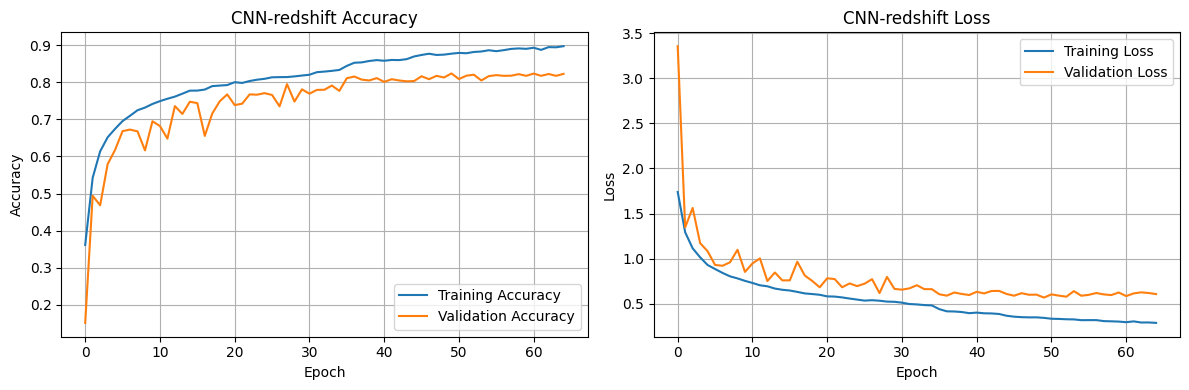

In [ ]:
# Plot training and validation curve for Model B( CNN with redshift late fusion)
def plot_training_history(history, model_name="Model"):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} Accuracy') # Used f-string for dynamic title
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} Loss') # Used f-string for dynamic title
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history, model_name="CNN-redshift")

In [ ]:
# Standard test evaluation
test_loss, test_acc = model_b.evaluate(test_ds, verbose=1)

print(f"Test Accuracy (Classical): {test_acc:.4f}")
print(f"Test Loss       (Classical): {test_loss:.4f}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8193 - loss: 0.5806
Test Accuracy (Classical): 0.8140
Test Loss       (Classical): 0.5595


In [ ]:
#
def get_classical_predictions(model, test_ds):
    all_preds = []
    all_labels = []

    # test_ds returns → (inputs_dict, labels)
    for features, labels in test_ds:

        # Run model (dropout disabled)
        logits = model(features, training=False)

        # Convert logits → probabilities
        probs = tf.nn.softmax(logits, axis=-1)

        all_preds.append(probs.numpy())
        all_labels.append(labels.numpy())

    # Combine batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Convert probabilities → predicted class indices
    y_pred_red = np.argmax(all_preds, axis=1)
    y_true_red  = all_labels

    return y_true_red, y_pred_red


In [ ]:
#
y_true_red, y_pred_red = get_classical_predictions(model_b, test_ds)

accuracy  = accuracy_score(y_true_red, y_pred_red)
precision = precision_score(y_true_red, y_pred_red, average='macro')
recall    = recall_score(y_true_red, y_pred_red, average='macro')
f1        = f1_score(y_true_red, y_pred_red, average='macro')

print("Classical Model Evaluation (No MC Dropout), redshift")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Classical Model Evaluation (No MC Dropout), redshift
Accuracy : 0.8140
Precision: 0.7851
Recall   : 0.8042
F1-score : 0.7925


In [ ]:
print("\nClassification Report (Macro averaged) redshift:")
print(classification_report(y_true_red, y_pred_red, target_names=class_names))


Classification Report (Macro averaged) redshift:
                         precision    recall  f1-score   support

              Disturbed       0.51      0.45      0.47       159
                Merging       0.81      0.88      0.84       275
           Round Smooth       0.90      0.92      0.91       395
In-between Round Smooth       0.87      0.91      0.89       303
    Cigar Shaped Smooth       0.65      0.84      0.73        50
          Barred Spiral       0.84      0.79      0.81       304
  Unbarred Tight Spiral       0.74      0.79      0.76       271
  Unbarred Loose Spiral       0.74      0.66      0.70       392
  Edge-on without Bulge       0.86      0.91      0.88       205
     Edge-on with Bulge       0.95      0.90      0.92       280

               accuracy                           0.81      2634
              macro avg       0.79      0.80      0.79      2634
           weighted avg       0.81      0.81      0.81      2634



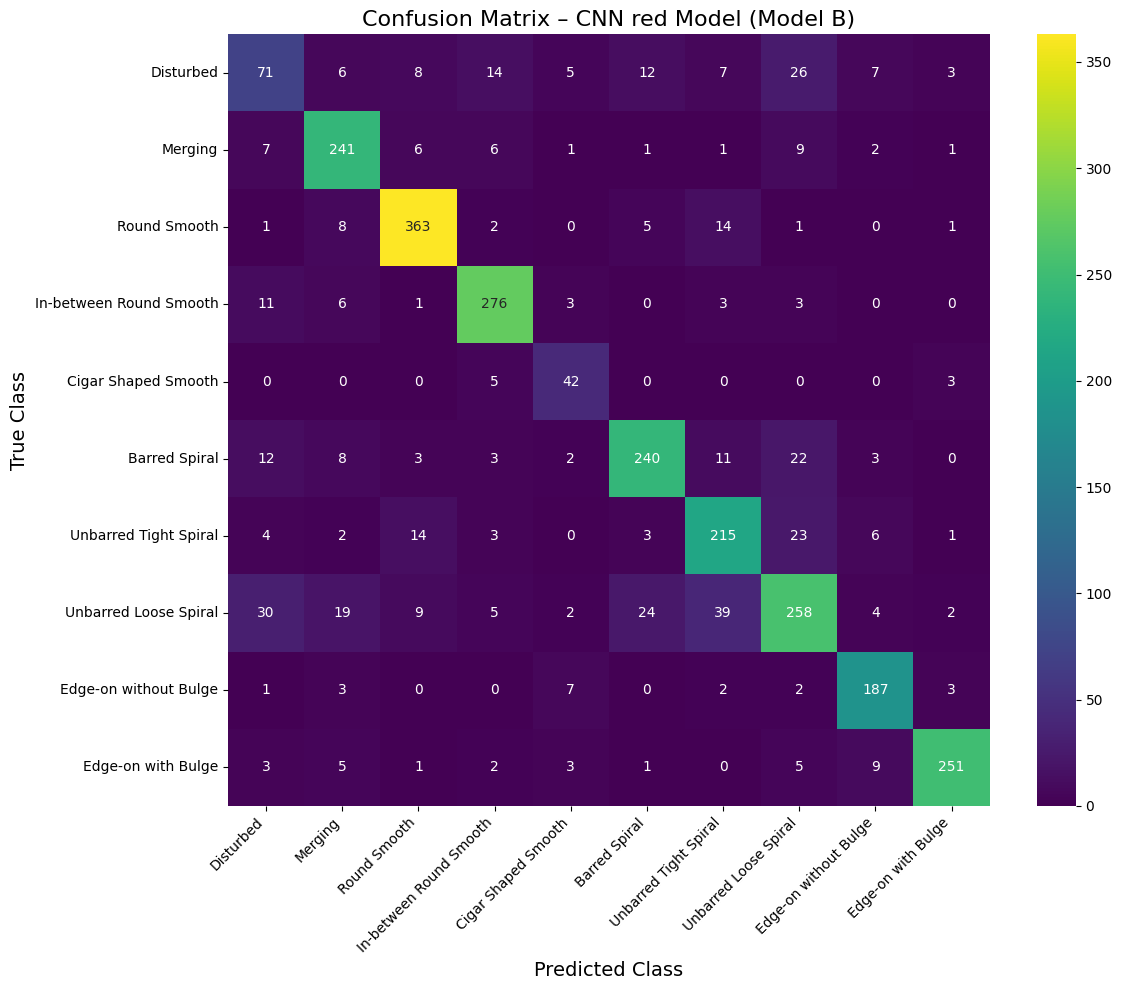

In [ ]:
# confuson matrix for Model B
cm_b = confusion_matrix(y_true_red, y_pred_red)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_b,
    annot=True,        # show numbers
    fmt="d",           # integer formatting
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – CNN red Model (Model B)", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



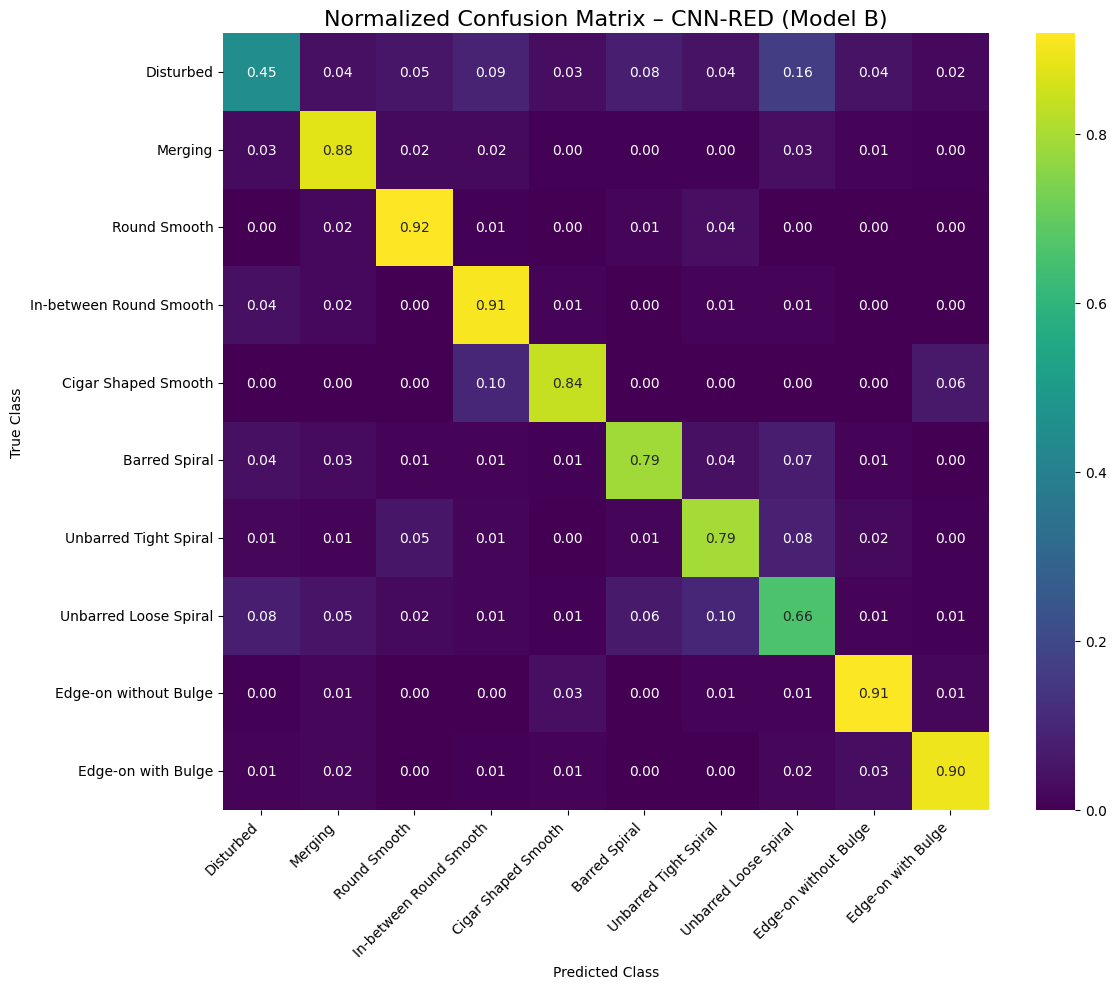

In [ ]:
# Normalized confusion Matrix for Model B
cm_norm_b = cm_b.astype("float") / cm_b.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm_b,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix – CNN-RED (Model B)", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
#Model C- CNN with redshift and MC dropout

def build_galaxynet_cnn_mc_latefusion(dropout_p=0.21, num_classes=10):

    # IMAGE INPUT
    image_input = layers.Input(shape=(64, 64, 3), name="image_input")

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Global pooling
    img_features = layers.GlobalAveragePooling2D()(x)

    # REDSHIFT BRANCH
    redshift_input = layers.Input(shape=(1,), name="redshift_input")

    z = layers.Dense(64, activation="relu")(redshift_input)
    z = layers.Dropout(dropout_p)(z, training=True)

    z = layers.Dense(32, activation="relu")(z)
    z = layers.Dropout(dropout_p)(z, training=True)
    # CRITICAL ADDITION: Gating with MC Dropout
    gate = layers.Dense(32, activation="sigmoid", name="z_gate")(z)
    gate = layers.Dropout(dropout_p/2)(gate, training=True)
    z_weighted = layers.Multiply(name="z_weighted")([z, gate])

    # LATE FUSION
    fused = layers.concatenate([img_features, z_weighted])

    fused = layers.Dense(256, activation="relu")(fused)
    fused = layers.Dropout(dropout_p)(fused, training=True)

    fused = layers.Dense(128, activation="relu")(fused)
    fused = layers.Dropout(dropout_p)(fused, training=True)

    logits = layers.Dense(num_classes)(fused)

    model = models.Model(
        inputs=[image_input, redshift_input],
        outputs=logits,
        name="GalaxyNet_CNN_MC_LateFusion"
    )

    return model


In [ ]:
# Building model C
model_c = build_galaxynet_cnn_mc_latefusion(dropout_p=0.21)
model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
model_c.summary()


Model: "GalaxyNet_CNN_MC_LateFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_4 │ (None, 32, 32,    │          0 │ max_pooling2d_4[… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     18,496 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_5 │ (None, 16, 16,    │          0 │ max_pooling2d_5[… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │     73,856 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_13[0][0] 

 Total params: 1,287,530 (4.91 MB)

 Trainable params: 1,285,610 (4.90 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# Callbacks for Model C
callbacks_c = [
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        min_delta = 0.001,
        mode ='min',
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate reduction
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    # Model checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        'models/cnn_mc_dropout_best.keras',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )]

In [ ]:
# Training for Modle C
start_time = time.time()
history = model_c.fit(
    train_ds,
    validation_data=val_ds,
    epochs=120,
    callbacks=callbacks_c,
    verbose = 1
)
end_time = time.time()
training_time_sec = end_time - start_time
print(f"Training time (seconds): {training_time_sec:.2f}")

Epoch 1/120
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1677 - loss: 2.2854
Epoch 1: val_loss improved from inf to 2.56760, saving model to models/cnn_mc_dropout_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.1678 - loss: 2.2848 - val_accuracy: 0.1496 - val_loss: 2.5676 - learning_rate: 3.0000e-04
Epoch 2/120
284/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3415 - loss: 1.7749
Epoch 2: val_loss improved from 2.56760 to 1.72396, saving model to models/cnn_mc_dropout_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3420 - loss: 1.7735 - val_accuracy: 0.3365 - val_loss: 1.7240 - learning_rate: 3.0000e-04
Epoch 3/120
284/288 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4361 - loss: 1.5181
Epoch 3: val_loss improved from 1.72396 to 1.31359, saving model to models/cnn_mc_dropout_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4364 - loss: 1.5175 - val_accuracy: 0.5272 - val_loss: 1.3136 - learning_rate: 3.0000e-04
E

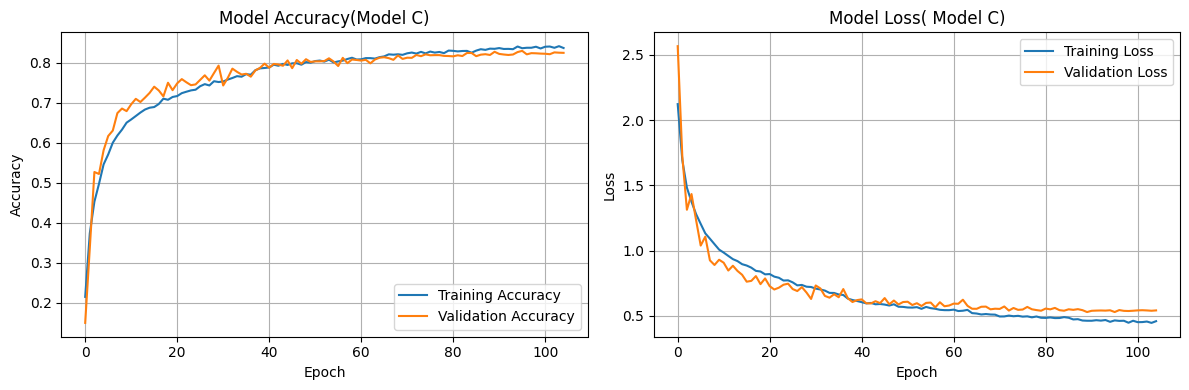

In [ ]:
# Training and validation plot for Model C
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy(Model C)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss( Model C)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

In [ ]:
# Classical Evaluation (Non-Bayesian)
# Standard test evaluation
test_loss, test_acc = model_c.evaluate(test_ds, verbose=1)

print(f"Test Accuracy (Classical): {test_acc:.4f}")
print(f"Test Loss       (Classical): {test_loss:.4f}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8139 - loss: 0.5720
Test Accuracy (Classical): 0.8159
Test Loss       (Classical): 0.5347


In [ ]:
#
def get_classical_predictions(model, test_ds):
    all_preds = []
    all_labels = []

    # test_ds returns → (inputs_dict, labels)
    for features, labels in test_ds:

        # Run model (dropout disabled)
        logits = model(features, training=False)

        # Convert logits → probabilities
        probs = tf.nn.softmax(logits, axis=-1)

        all_preds.append(probs.numpy())
        all_labels.append(labels.numpy())

    # Combine batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Convert probabilities → predicted class indices
    y_pred = np.argmax(all_preds, axis=1)
    y_true = all_labels

    return y_true, y_pred


In [ ]:
#
y_true, y_pred = get_classical_predictions(model_c, test_ds)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

print("Classical Model Evaluation (No MC Dropout)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Classical Model Evaluation (No MC Dropout)
Accuracy : 0.8155
Precision: 0.7886
Recall   : 0.8119
F1-score : 0.7972


In [ ]:
print("\nClassification Report (Macro averaged):")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report (Macro averaged):
                         precision    recall  f1-score   support

              Disturbed       0.49      0.47      0.48       159
                Merging       0.84      0.87      0.86       275
           Round Smooth       0.91      0.90      0.91       395
In-between Round Smooth       0.92      0.92      0.92       303
    Cigar Shaped Smooth       0.65      0.90      0.76        50
          Barred Spiral       0.75      0.86      0.80       304
  Unbarred Tight Spiral       0.75      0.79      0.77       271
  Unbarred Loose Spiral       0.76      0.62      0.68       392
  Edge-on without Bulge       0.90      0.88      0.89       205
     Edge-on with Bulge       0.91      0.91      0.91       280

               accuracy                           0.82      2634
              macro avg       0.79      0.81      0.80      2634
           weighted avg       0.82      0.82      0.81      2634



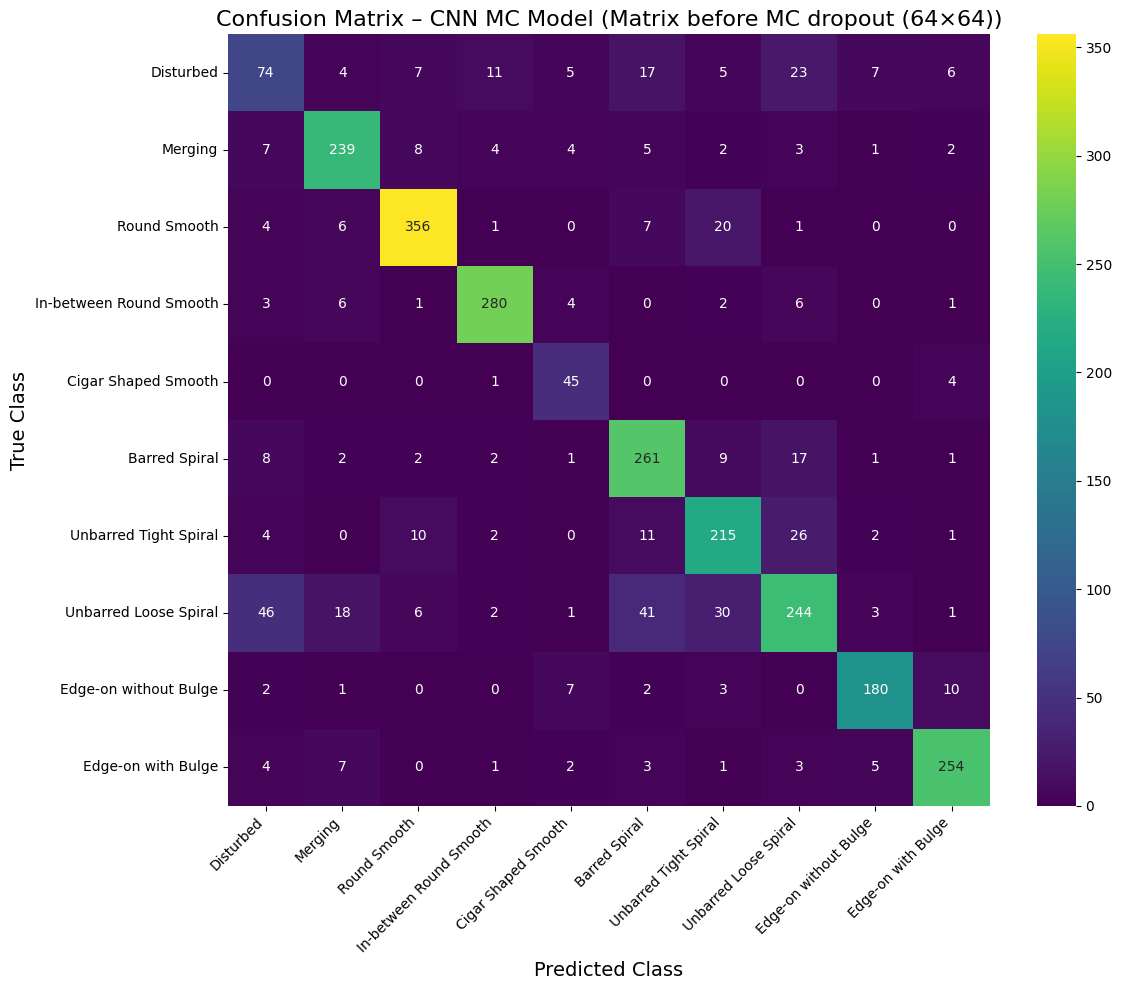

In [ ]:
# confuson matrix for Model C
cm_c = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_c,
    annot=True,        # show numbers
    fmt="d",           # integer formatting
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – CNN MC Model (Matrix before MC dropout (64×64))", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



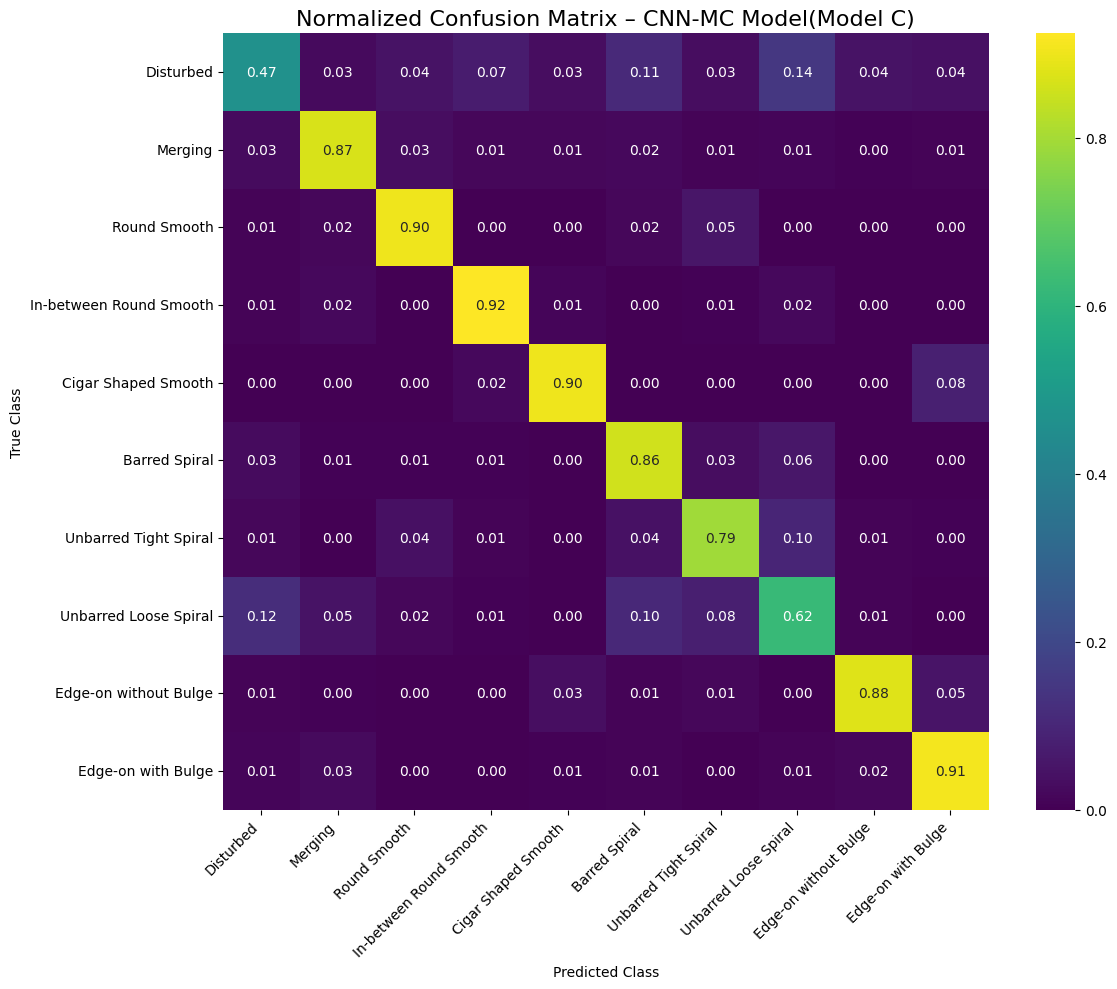

In [ ]:

# Normalized confusion Matrix for Model C
cm_norm = cm_c.astype("float") / cm_c.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix – CNN-MC Model(Model C)", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [ ]:
# Class for the MC dropout
def mc_dropout_predict(model, dataset, n_samples=30, batch_size_predict=64):
    """
    Bayesian inference with MC Dropout for a two-input (late-fusion) model.
    dataset returns: ({'image_input': img, 'redshift_input': z}, label)
    """

    # STEP 1: Reconstruct full test arrays
    imgs, zs, labs = [], [], []

    for features, labels in dataset:
        imgs.append(features["image_input"].numpy())       # (B, 64,64,3)
        zs.append(features["redshift_input"].numpy())      # (B, 1)
        labs.append(labels.numpy())

    imgs = np.concatenate(imgs, axis=0)
    zs   = np.concatenate(zs, axis=0)
    labs = np.concatenate(labs, axis=0)

    N = imgs.shape[0]
    print(f"Collected {N} evaluation samples.\n")

    # STEP 2: Monte Carlo sampling loop
    all_preds_mc = []

    for i in range(n_samples):
        if (i + 1) % 5 == 0 or i == 0:
            print(f"  Pass {i+1}/{n_samples} ...")

        batch_preds = []

        for j in range(0, N, batch_size_predict):
            end = min(j + batch_size_predict, N)

            batch_imgs = imgs[j:end]
            batch_z    = zs[j:end]

            # must pass dict with both inputs
            inputs = {
                "image_input": batch_imgs,
                "redshift_input": batch_z
            }

            # dropout active → Bayesian inference
            logits = model(inputs, training=True)
            probs  = tf.nn.softmax(logits, axis=-1).numpy()

            batch_preds.append(probs)

        all_preds_mc.append(np.concatenate(batch_preds, axis=0))

    all_preds = np.array(all_preds_mc)  # shape: (T, N, C)

    # STEP 3: Uncertainty statistics
    mean_pred = np.mean(all_preds, axis=0)
    std_pred  = np.std(all_preds, axis=0)

    predictive_entropy = -np.sum(mean_pred * np.log(mean_pred + 1e-9), axis=1)

    aleatoric_entropy = -np.mean(
        np.sum(all_preds * np.log(all_preds + 1e-9), axis=2),
        axis=0
    )

    mutual_information = predictive_entropy - aleatoric_entropy

    variation_ratio = 1 - np.max(mean_pred, axis=1)

    return {
        "mean_pred": mean_pred,
        "std_pred": std_pred,
        "predictive_entropy": predictive_entropy,
        "aleatoric_entropy": aleatoric_entropy,
        "mutual_information": mutual_information,
        "variation_ratio": variation_ratio,
        "y_true": labs,
        "all_preds": all_preds
    }


In [ ]:
# MC dropout pass interfece
results = mc_dropout_predict(model_c, test_ds, n_samples=50, batch_size_predict=batch_size)

Collected 2634 evaluation samples.

  Pass 1/50 ...
  Pass 5/50 ...
  Pass 10/50 ...
  Pass 15/50 ...
  Pass 20/50 ...
  Pass 25/50 ...
  Pass 30/50 ...
  Pass 35/50 ...
  Pass 40/50 ...
  Pass 45/50 ...
  Pass 50/50 ...


In [ ]:
#  Final Predictions (after MC pass)
mean_prediction = results['mean_pred']  # Shape: (n_galaxies, n_classes)
true_labels = results["y_true"]
predicted_labels = np.argmax(mean_prediction, axis=1)  # Predicted class for each galaxy
confidence_scores = np.max(mean_prediction, axis=1)     # Confidence for each prediction

print(f"FINAL PREDICTIONS:")
print(f"Predicted classes shape: {predicted_labels.shape}")
print(f"Confidence scores shape: {confidence_scores.shape}")
print(f"First 10 predictions: {predicted_labels[:10]}")
print(f"First 10 confidences: {confidence_scores[:10].round(3)}")

FINAL PREDICTIONS:
Predicted classes shape: (2634,)
Confidence scores shape: (2634,)
First 10 predictions: [8 4 7 3 7 8 4 5 5 3]
First 10 confidences: [0.847 0.749 0.765 0.915 0.811 0.931 0.947 0.991 0.338 0.921]


In [ ]:
# step 1a:Compute Accuracy
mc_accuracy = accuracy_score(true_labels, predicted_labels)
print(f"MC Dropout Accuracy: {mc_accuracy:.4f}")

MC Dropout Accuracy: 0.8079


In [ ]:
# step 1b:Calculation of Precision, Recall, and F1-Score
# Per-class precision, recall, f1
precision_per_class = precision_score(true_labels, predicted_labels, average=None)
recall_per_class = recall_score(true_labels, predicted_labels, average=None)
f1_per_class = f1_score(true_labels, predicted_labels, average=None)

# Macro averaged scores
precision_macro = precision_score(true_labels, predicted_labels, average='macro')
recall_macro = recall_score(true_labels, predicted_labels, average='macro')
f1_macro = f1_score(true_labels, predicted_labels, average='macro')

# Print macro scores
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

# Print per-class scores
for i, class_name in enumerate(class_names):
    print(f"{class_name}: Precision={precision_per_class[i]:.4f}, Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")

Macro Precision: 0.7714
Macro Recall: 0.8104
Macro F1-score: 0.7838
Disturbed: Precision=0.4620, Recall=0.4969, F1=0.4788
Merging: Precision=0.8387, Recall=0.8509, F1=0.8448
Round Smooth: Precision=0.9305, Recall=0.8810, F1=0.9051
In-between Round Smooth: Precision=0.9205, Recall=0.9175, F1=0.9190
Cigar Shaped Smooth: Precision=0.5109, Recall=0.9400, F1=0.6620
Barred Spiral: Precision=0.7943, Recall=0.8257, F1=0.8097
Unbarred Tight Spiral: Precision=0.7428, Recall=0.7565, F1=0.7495
Unbarred Loose Spiral: Precision=0.7561, Recall=0.6327, F1=0.6889
Edge-on without Bulge: Precision=0.8472, Recall=0.8927, F1=0.8694
Edge-on with Bulge: Precision=0.9107, Recall=0.9107, F1=0.9107


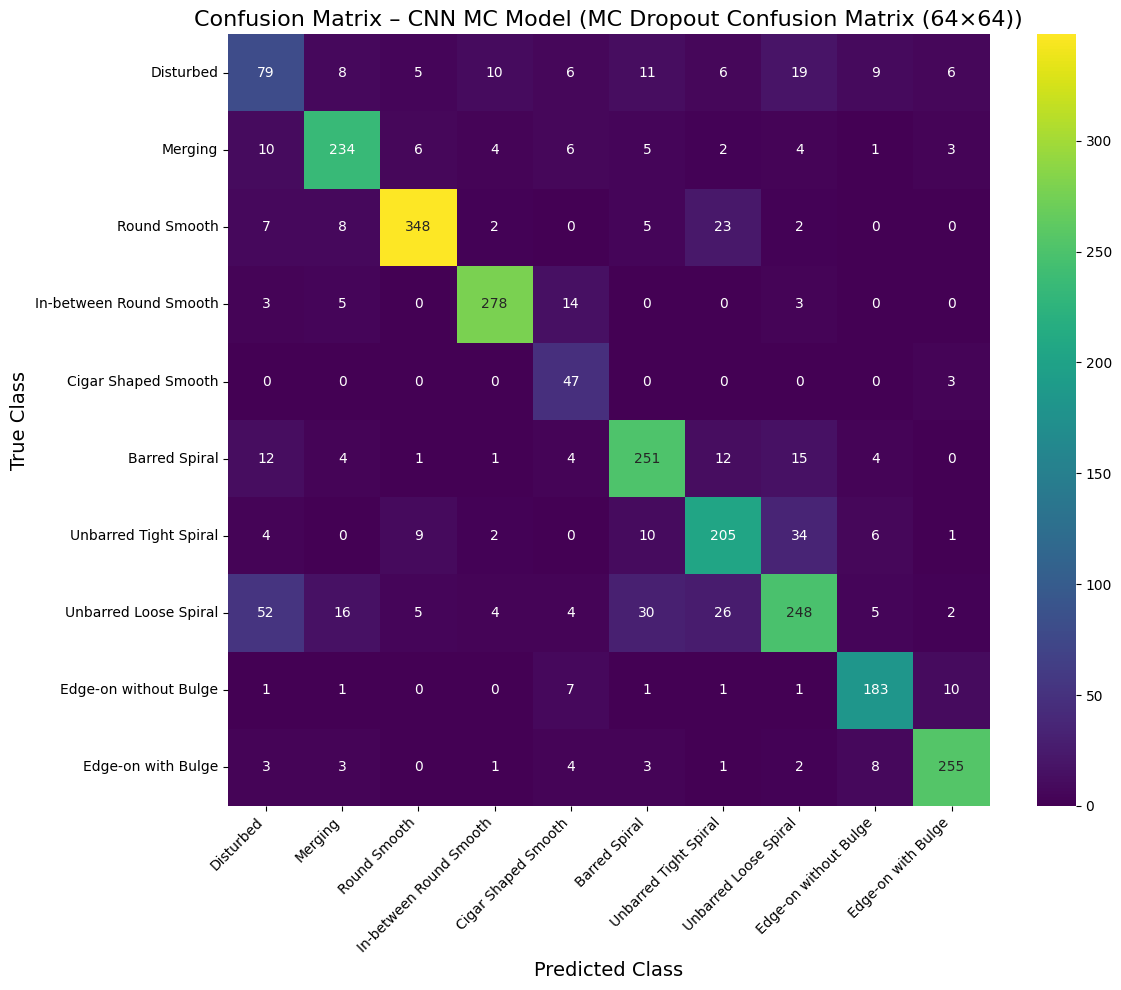

In [ ]:
# confuson matrix for Model C
cm_d = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_d,
    annot=True,        # show numbers
    fmt="d",           # integer formatting
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – CNN MC Model (MC Dropout Confusion Matrix (64×64))", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



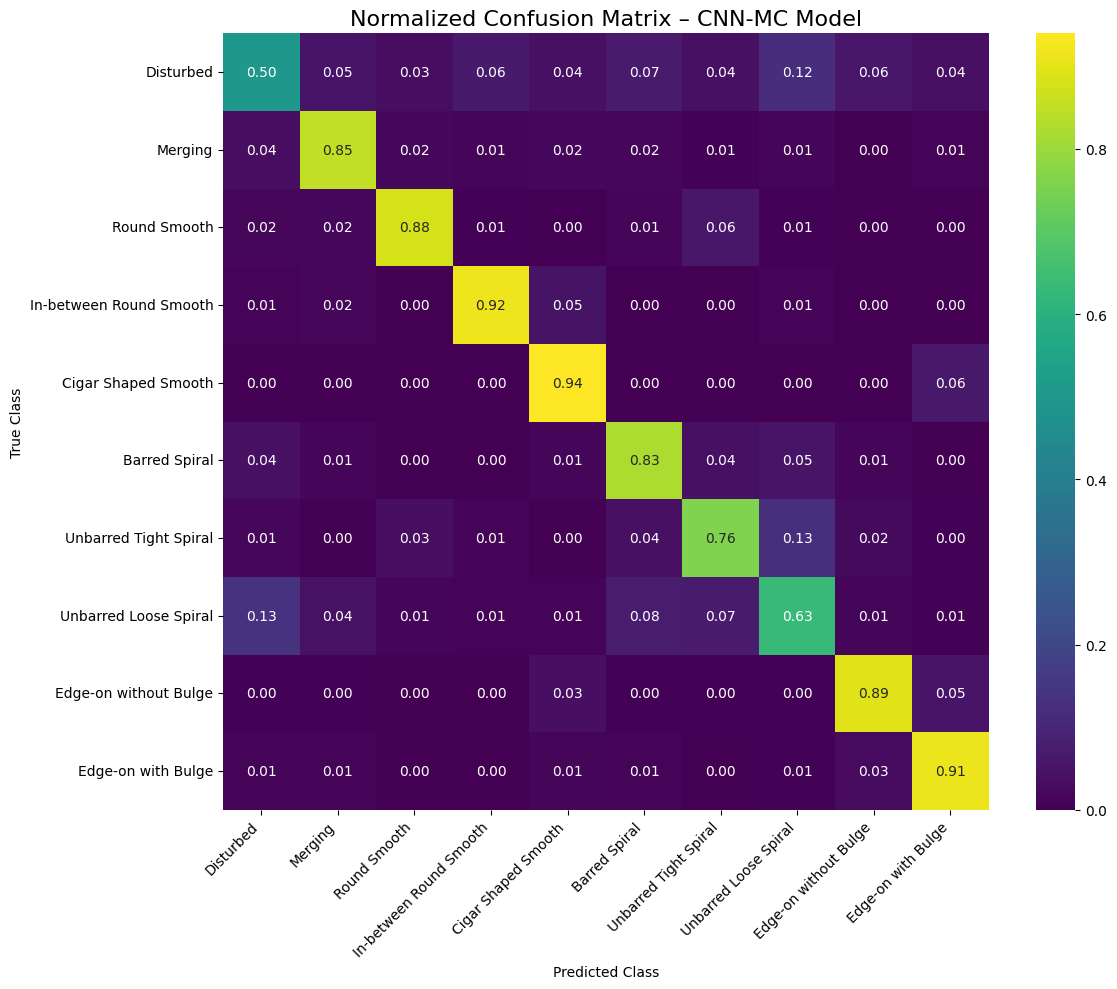

In [ ]:

# Normalized confusion Matrix for Model C
cm_norm_mc = cm_d.astype("float") / cm_d.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm_mc,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix – CNN-MC Model", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Class 0: Accuracy = 0.497, Mean Entropy = 0.901
Class 1: Accuracy = 0.851, Mean Entropy = 0.546
Class 2: Accuracy = 0.881, Mean Entropy = 0.452
Class 3: Accuracy = 0.917, Mean Entropy = 0.530
Class 4: Accuracy = 0.940, Mean Entropy = 0.434
Class 5: Accuracy = 0.826, Mean Entropy = 0.563
Class 6: Accuracy = 0.756, Mean Entropy = 0.767
Class 7: Accuracy = 0.633, Mean Entropy = 0.955
Class 8: Accuracy = 0.893, Mean Entropy = 0.356
Class 9: Accuracy = 0.911, Mean Entropy = 0.318


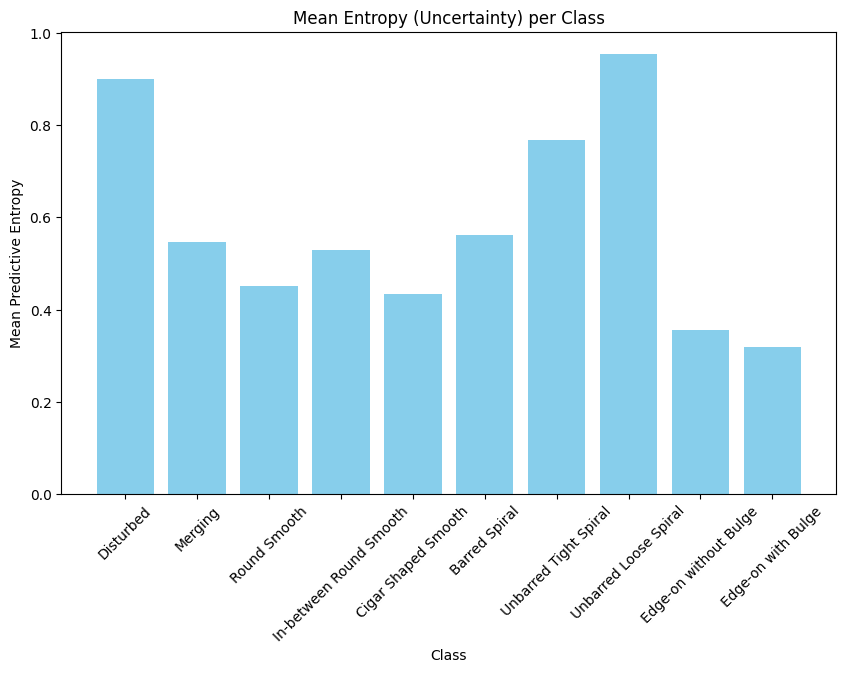

In [ ]:
# step 1d:Per-class accuracy and entropy(uncertainty) comparison
num_classes = len(np.unique(true_labels))
per_class_accuracy = []
mean_entropies = []

# Define uncertainty using the results from mc_dropout_predict
uncertainty = results['predictive_entropy']

for class_idx in range(num_classes):
    class_mask = true_labels == class_idx

    # Calculate per-class accuracy
    acc = np.mean(predicted_labels[class_mask] == true_labels[class_mask])
    per_class_accuracy.append(acc)
    #print(f"Class {class_idx} accuracy: {acc:.3f}")

    # Calculate mean predictive entropy
    mean_entropy = uncertainty[class_mask].mean()
    mean_entropies.append(mean_entropy)
    print(f"Class {class_idx}: Accuracy = {acc:.3f}, Mean Entropy = {mean_entropy:.3f}")


plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), mean_entropies, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Mean Predictive Entropy')
plt.title('Mean Entropy (Uncertainty) per Class')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

In [ ]:
#  step e: Detailed Classification Report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)


                         precision    recall  f1-score   support

              Disturbed       0.46      0.50      0.48       159
                Merging       0.84      0.85      0.84       275
           Round Smooth       0.93      0.88      0.91       395
In-between Round Smooth       0.92      0.92      0.92       303
    Cigar Shaped Smooth       0.51      0.94      0.66        50
          Barred Spiral       0.79      0.83      0.81       304
  Unbarred Tight Spiral       0.74      0.76      0.75       271
  Unbarred Loose Spiral       0.76      0.63      0.69       392
  Edge-on without Bulge       0.85      0.89      0.87       205
     Edge-on with Bulge       0.91      0.91      0.91       280

               accuracy                           0.81      2634
              macro avg       0.77      0.81      0.78      2634
           weighted avg       0.81      0.81      0.81      2634



In [ ]:
#2. Uncertainty Quantification Metrics(Quantify model/data uncertainty/MC Dropout)
# Predictive Entropy(Measures total uncertainty in prediction)
uncertainty = results['predictive_entropy']      # Total uncertainty(uncertainty/entropy)

# Mutual Information (Epistemic Uncertainty)
mutual_info = results['mutual_information']      # Model uncertainty/Epistemic uncertainty

# Aleatoric Uncertainty(noise inherent in input data, irreducible by more data)
aleatoric = results['aleatoric_entropy']     # Data uncertainty/Aleatoric uncertainty

print(f"\n UNCERTAINTY METRICS:")
print(f"Predictive entropy shape: {uncertainty.shape}")
print(f"Mutual information shape: {mutual_info.shape}")
print(f"Aleatoric uncertainty shape: {aleatoric.shape}")

print(f"\n UNCERTAINTY STATISTICS:")
print(f"Average predictive entropy: {np.mean(uncertainty):.4f}")
print(f"Average mutual information: {np.mean(mutual_info):.4f}")
print(f"Average aleatoric uncertainty: {np.mean(aleatoric):.4f}")
print(f"Uncertainty range: [{uncertainty.min():.4f}, {uncertainty.max():.4f}]")


 UNCERTAINTY METRICS:
Predictive entropy shape: (2634,)
Mutual information shape: (2634,)
Aleatoric uncertainty shape: (2634,)

 UNCERTAINTY STATISTICS:
Average predictive entropy: 0.5959
Average mutual information: 0.1023
Average aleatoric uncertainty: 0.4936
Uncertainty range: [0.0015, 1.9468]


Found 188 samples with high uncertainty and low confidence.


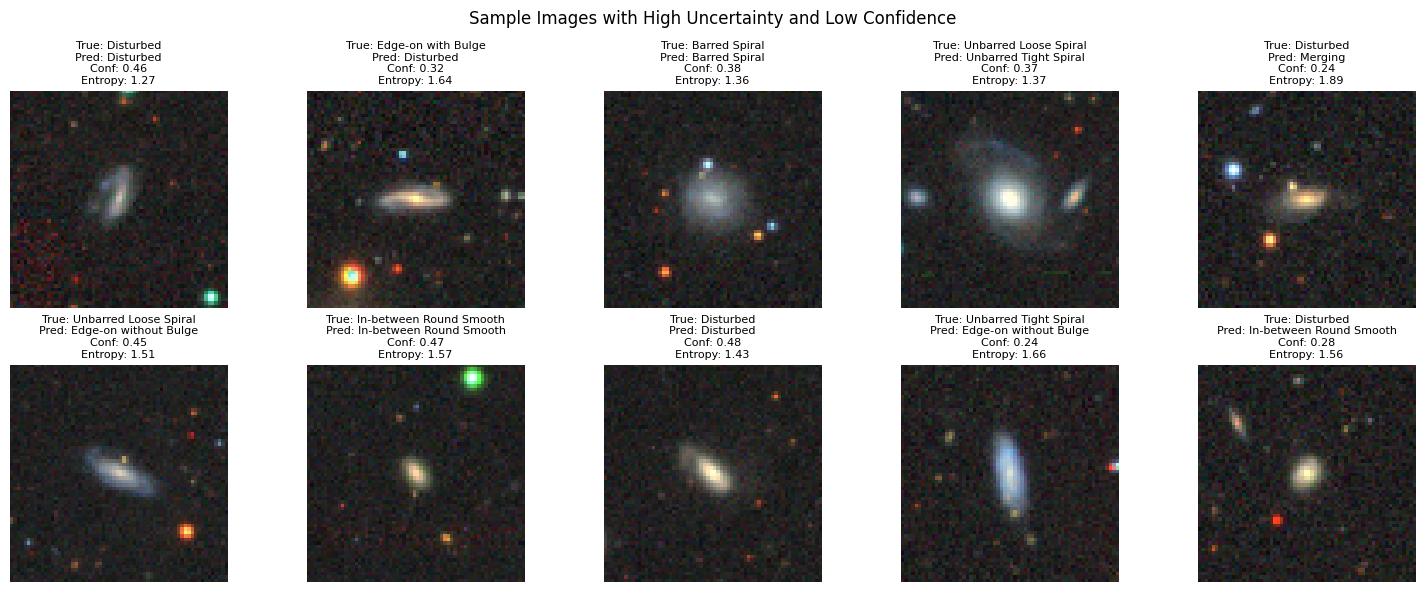

In [ ]:
# Define thresholds for high uncertainty and low confidence
#STEP 1: Extract test images for visualization

test_imgs_list = []
for features, _ in test_ds:
    test_imgs_list.append(features["image_input"].numpy())

# concatenate into (N, 64, 64, 3)
test_imgs = np.concatenate(test_imgs_list, axis=0)

uncertainty_threshold = np.percentile(results['predictive_entropy'], 90) # e.g., top 10% most uncertain
confidence_threshold = np.percentile(confidence_scores, 10) # e.g., bottom 10% least confident

# Find indices of samples meeting the criteria
high_uncertainty_low_confidence_indices = np.where(
    (results['predictive_entropy'] > uncertainty_threshold) &
    (confidence_scores < confidence_threshold)
)[0]

print(f"Found {len(high_uncertainty_low_confidence_indices)} samples with high uncertainty and low confidence.")

# Display a few sample images from these indices
num_samples_to_show = min(10, len(high_uncertainty_low_confidence_indices)) # Display up to 10 samples

if num_samples_to_show > 0:
    plt.figure(figsize=(15, 6))
    for i in range(num_samples_to_show):
        plt.subplot(2, 5, i + 1) # Added subplot for correct layout
        idx = high_uncertainty_low_confidence_indices[i]
        # Corrected: use 'test_images' instead of 'images_test'
        plt.imshow(test_imgs[idx]) # Display RGB channels only for visualization
        plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[predicted_labels[idx]]}\nConf: {confidence_scores[idx]:.2f}\nEntropy: {results['predictive_entropy'][idx]:.2f}", fontsize=8)
        plt.axis('off')
    plt.suptitle('Sample Images with High Uncertainty and Low Confidence')
    plt.tight_layout()
    plt.show()
else:
    print("No samples found meeting the criteria.")

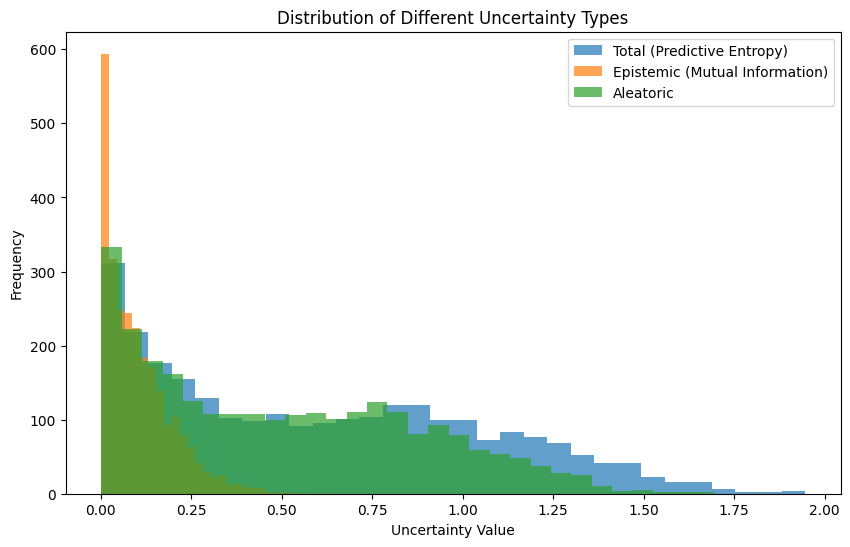

In [ ]:
# 3. Visualizations Related to Uncertainty
# Step 3a: Histogram of Uncertainty Distributions( all three)
plt.figure(figsize=(10,6))
plt.hist(uncertainty, bins=30, alpha=0.7, label='Total (Predictive Entropy)')
plt.hist(mutual_info, bins=30, alpha=0.7, label='Epistemic (Mutual Information)')
plt.hist(aleatoric, bins=30, alpha=0.7, label='Aleatoric')
plt.xlabel("Uncertainty Value")
plt.ylabel("Frequency")
plt.title("Distribution of Different Uncertainty Types")
plt.legend()
plt.show()

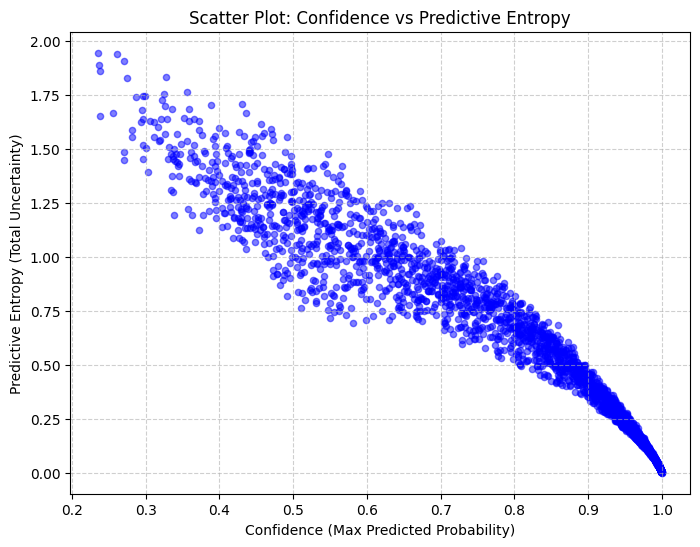

In [ ]:
# step 3b: Scatter plot: Confidence vs Predictive Entropy
plt.figure(figsize=(8,6))
plt.scatter(confidence_scores, uncertainty, alpha=0.5, s=20, c='blue')
plt.xlabel('Confidence (Max Predicted Probability)')
plt.ylabel('Predictive Entropy (Total Uncertainty)')
plt.title('Scatter Plot: Confidence vs Predictive Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

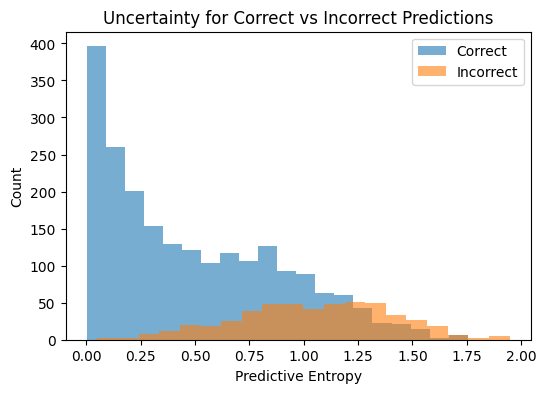

In [ ]:
# Step 3c: Compare Correct vs Incorrect Predictions
correct = (predicted_labels == true_labels)
plt.figure(figsize=(6,4))
plt.hist(uncertainty[correct], bins=20, alpha=0.6, label='Correct')
plt.hist(uncertainty[~correct], bins=20, alpha=0.6, label='Incorrect')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.legend()
plt.title('Uncertainty for Correct vs Incorrect Predictions')
plt.show()

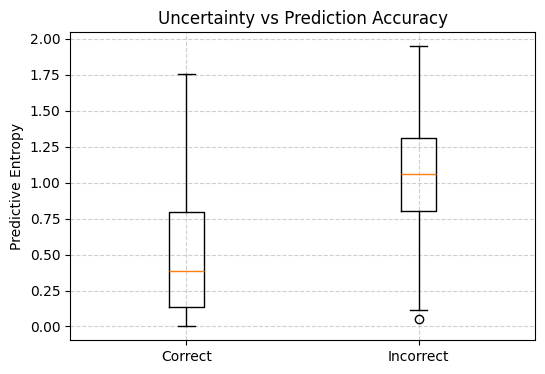

In [ ]:
# Boxplot: Uncertainty vs Correctness
correct = (predicted_labels == true_labels)
plt.figure(figsize=(6,4))
#plt.boxplot([uncertainty[correct], uncertainty[~correct]], labels=['Correct', 'Incorrect'],patch_artist=True,
    #boxprops=dict(facecolor='lightblue', color='black'),
    #medianprops=dict(color='red'))
plt.boxplot(
    [uncertainty[correct], uncertainty[~correct]],
    tick_labels=['Correct', 'Incorrect']
)
plt.title('Uncertainty vs Prediction Accuracy')
plt.ylabel('Predictive Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


predictions shape: (50, 2634, 10)
Average Variation Ratio: 0.10677296886864085


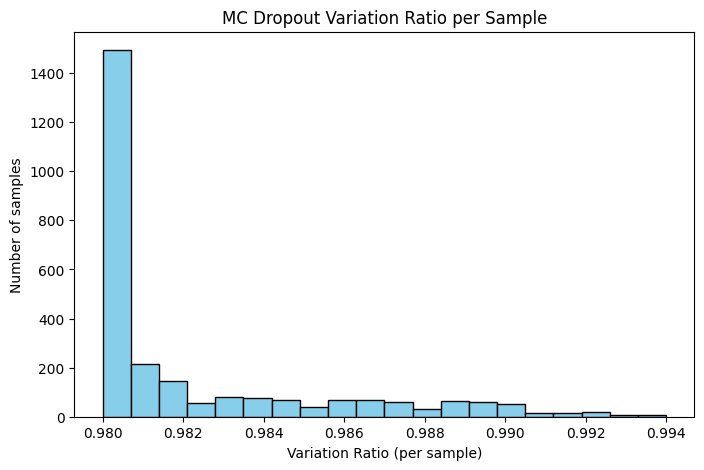

In [ ]:
# step 3d: Variation Ratio
# predictions: shape (num_mc_samples, num_test_samples, num_classes)
predictions = results['all_preds']
print(f"predictions shape: {predictions.shape}")
mc_classes = np.argmax(predictions, axis=2)  # shape: (num_mc_samples, num_test_samples)

# For each test sample, find the most common predicted class count
mode_counts = np.apply_along_axis(lambda x: np.bincount(x, minlength=num_classes).max(), axis=0, arr=mc_classes)

variation_ratio = 1 - (mode_counts /predictions.shape[0])
print("Average Variation Ratio:", variation_ratio.mean())

# Compute variation ratio per test sample
num_test_samples = predictions.shape[1]
num_mc_samples = predictions.shape[0]
variation_ratio_per_sample = 1 - np.array([
    np.mean(mc_classes[:, i] == np.bincount(mc_classes[:, i]).argmax()) / num_mc_samples
    for i in range(num_test_samples)
])

# Histogram of variation ratios
plt.figure(figsize=(8,5))
plt.hist(variation_ratio_per_sample, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Variation Ratio (per sample)')
plt.ylabel('Number of samples')
plt.title('MC Dropout Variation Ratio per Sample')
plt.show()

Class 0 entropy: 0.9006588
Class 1 entropy: 0.54641765
Class 2 entropy: 0.45190755
Class 3 entropy: 0.52962554
Class 4 entropy: 0.4344984
Class 5 entropy: 0.5628769
Class 6 entropy: 0.7670747
Class 7 entropy: 0.9548787
Class 8 entropy: 0.35624877
Class 9 entropy: 0.3182456


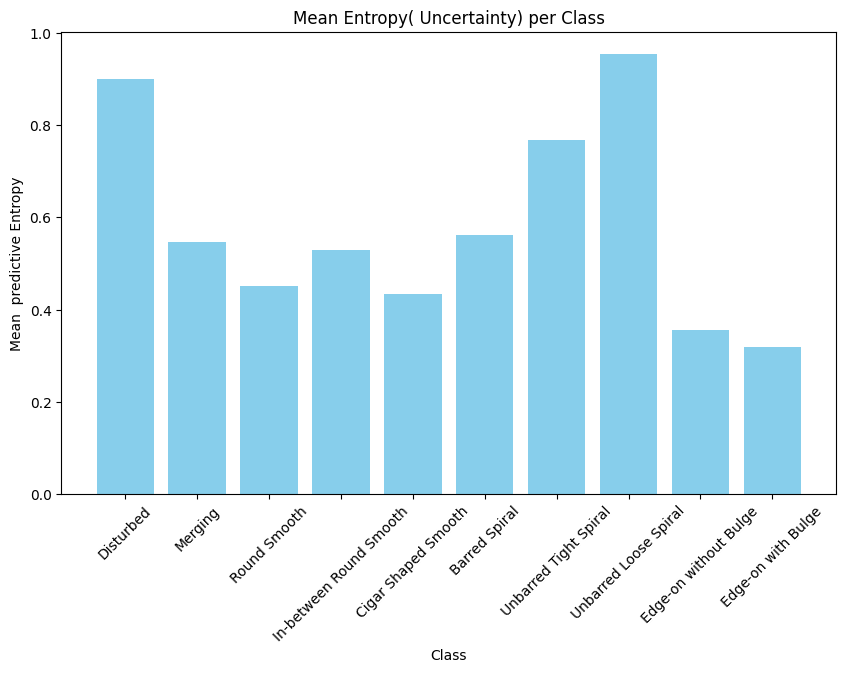

In [ ]:
# Per-Class Uncertainty(extra)

mean_entropies = []
for class_idx in range(num_classes):
    class_mask = (true_labels == class_idx)
    mean_entropy = uncertainty[class_mask].mean()
    mean_entropies.append(mean_entropy)
    print(f"Class {class_idx} entropy:", uncertainty[class_mask].mean())


plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), mean_entropies, color = 'skyblue')
plt.xlabel('Class')
plt.ylabel('Mean  predictive Entropy')
plt.title('Mean Entropy( Uncertainty) per Class')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

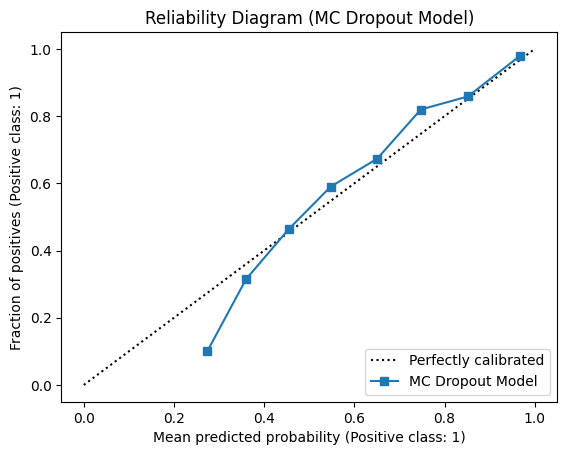

In [ ]:
# Step 4a: Reliability Diagram (Calibration Plot)
from sklearn.calibration import CalibrationDisplay
# Create true/false correctness per sample
correct = (predicted_labels == true_labels)

# Plot reliability diagram
disp = CalibrationDisplay.from_predictions(
    y_true=correct,
    y_prob=confidence_scores,
    n_bins=10,
    strategy='uniform',
    name='MC Dropout Model'
)
plt.title("Reliability Diagram (MC Dropout Model)")
plt.show()

In [ ]:
# Step 4b: Compute Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        bin_mask = binids == i
        if np.sum(bin_mask) > 0:
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(y_true)
    return ece

# Compute ECE for MC Dropout model
ece_score = expected_calibration_error(correct, confidence_scores, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece_score:.4f}")

Expected Calibration Error (ECE): 0.0242


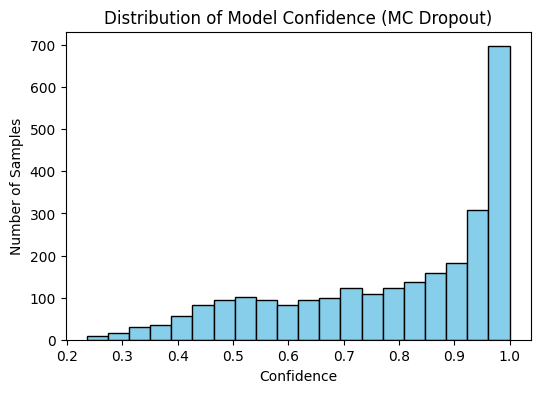

In [ ]:
# 4cHistogram of Confidence(optional)
plt.figure(figsize=(6,4))
plt.hist(confidence_scores, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Model Confidence (MC Dropout)')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')
plt.show()

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 33.5 MB/s eta 0:00:00


In [ ]:
import optuna
import tensorflow as tf


In [ ]:


# def build_cnn_rgb(
#     input_shape=(64, 64, 3),
#     num_classes=10,
#     dropout_rate=0.3
# ):
#     inputs = layers.Input(shape=input_shape)

#     # Block 1
#     x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D(2)(x)

#     # Block 2
#     x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D(2)(x)

#     # Block 3
#     x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D(2)(x)

#     # Block 4
#     x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D(2)(x)

#     # Global pooling
#     x = layers.GlobalAveragePooling2D()(x)

#     # Dense head
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.Dropout(dropout_rate)(x)

#     x = layers.Dense(128, activation="relu")(x)
#     x = layers.Dropout(dropout_rate)(x)

#     logits = layers.Dense(num_classes)(x)

#     return models.Model(inputs, logits, name="CNN_RGB_BASELINE")


In [ ]:
# def objective(trial):

#     # ---- Hyperparameters to tune ----
#     lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
#     dropout = trial.suggest_float("dropout", 0.2, 0.5)
#     optimizer_name = trial.suggest_categorical("optimizer", ["adam", "adamw"])

#     # ---- Build model ----
#     model = build_cnn_rgb(
#         input_shape=(64, 64, 3),
#         num_classes=10,
#         dropout_rate=dropout
#     )

#     # ---- Optimizer ----
#     if optimizer_name == "adamw":
#         optimizer = tf.keras.optimizers.AdamW(
#             learning_rate=lr,
#             weight_decay=1e-4
#         )
#     else:
#         optimizer = tf.keras.optimizers.Adam(
#             learning_rate=lr
#         )

#     # ---- Compile ----
#     model.compile(
#         optimizer=optimizer,
#         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#         metrics=["accuracy"]
#     )

#     # ---- Train ----
#     history = model.fit(
#         train_ds_rgb,
#         validation_data=val_ds_rgb,
#         epochs=40,
#         callbacks=[
#             tf.keras.callbacks.EarlyStopping(
#                 monitor="val_accuracy",
#                 patience=7,
#                 restore_best_weights=True
#             )
#         ],
#         verbose=0
#     )

#     # ---- Objective value ----
#     best_val_acc = max(history.history["val_accuracy"])
#     return best_val_acc


In [ ]:
# study = optuna.create_study(
#     direction="maximize",
#     study_name="cnn_rgb_baseline_optuna"
# )

# study.optimize(
#     objective,
#     n_trials=25,   # 20–25 is perfect for MSc
#     show_progress_bar=True
# )


[I 2025-12-19 21:54:53,971] A new study created in memory with name: cnn_rgb_baseline_optuna


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-12-19 22:00:17,282] Trial 0 finished with value: 0.8036460280418396 and parameters: {'lr': 0.0004763833616348727, 'dropout': 0.23427461004777272, 'optimizer': 'adamw'}. Best is trial 0 with value: 0.8036460280418396.
[I 2025-12-19 22:02:49,464] Trial 1 finished with value: 0.7330041527748108 and parameters: {'lr': 0.000992929550061851, 'dropout': 0.32551887514362626, 'optimizer': 'adamw'}. Best is trial 0 with value: 0.8036460280418396.
[I 2025-12-19 22:06:59,190] Trial 2 finished with value: 0.7759209871292114 and parameters: {'lr': 0.00027601191640766356, 'dropout': 0.3155759074393119, 'optimizer': 'adam'}. Best is trial 0 with value: 0.8036460280418396.
[I 2025-12-19 22:10:23,583] Trial 3 finished with value: 0.7713634371757507 and parameters: {'lr': 0.0006516113943599917, 'dropout': 0.2431733420029816, 'optimizer': 'adam'}. Best is trial 0 with value: 0.8036460280418396.
[I 2025-12-19 22:16:33,392] Trial 4 finished with value: 0.8055450320243835 and parameters: {'lr': 0.000

In [ ]:
# print("Best validation accuracy:", study.best_value)
# print("Best hyperparameters:")
# for k, v in study.best_params.items():
#     print(f"  {k}: {v}")


Best validation accuracy: 0.8146600723266602
Best hyperparameters:
  lr: 0.0003048838540586805
  dropout: 0.20998230859413847
  optimizer: adam
